# Task
Analyze a data using six different machine learning models ; logistic regression, random forest, support vector machine, extreme gradient boosting , naive bayes classifier and k- nearest neighbors.  check the feature importance and also the models performances using the Balance Accuracy, Accuracy, Sensitivity, Specificity, F1 score and Precision,AUROC, AUPRC.





In [46]:

from google.colab import drive

drive.mount('/content/drive')

# Correct way to read the CSV file
import pandas as pd
df = pd.read_csv('/content/drive/My Drive/data_final_16_5.csv')
display(df.head())
print(df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,country,gender,age_int,partnerinhh,country_new,sphus_new,chronicw9_new,adl2_new,iadl2_new,eurod_new,isced1997_r_new,age_group
0,1,Austria,Male,58,Yes,Austria,Good health,Chronic disease,No limitations,No limitations,Not depressed,Post-secondary education,50-64
1,2,Austria,Female,70,Yes,Austria,Good health,Chronic disease,No limitations,No limitations,Not depressed,Higher secondary education,65-79
2,3,Austria,Male,59,Yes,Austria,Poor health,Chronic disease,No limitations,No limitations,Not depressed,Higher secondary education,50-64
3,4,Austria,Male,97,No,Austria,Good health,Chronic disease,Limited,Limited,Not depressed,Lower secondary education,80 and above
4,5,Austria,Female,81,No,Austria,Poor health,Chronic disease,No limitations,No limitations,Not depressed,Higher secondary education,80 and above


(55492, 13)


## Data loading



In [47]:
print(df.info())
print(df['age_group'].unique())
# Check if 'Unnamed: 0' column exists before dropping
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
# Convert 'age2022' to numeric, coercing errors to NaN
#df['age2022'] = pd.to_numeric(df['age2022'], errors='coerce')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55492 entries, 0 to 55491
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       55492 non-null  int64 
 1   country          55492 non-null  object
 2   gender           55492 non-null  object
 3   age_int          55492 non-null  int64 
 4   partnerinhh      55492 non-null  object
 5   country_new      55492 non-null  object
 6   sphus_new        55492 non-null  object
 7   chronicw9_new    55492 non-null  object
 8   adl2_new         55492 non-null  object
 9   iadl2_new        55492 non-null  object
 10  eurod_new        55492 non-null  object
 11  isced1997_r_new  55492 non-null  object
 12  age_group        55492 non-null  object
dtypes: int64(2), object(11)
memory usage: 5.5+ MB
None
['50-64' '65-79' '80 and above']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55492 entries, 0 to 55491
Data columns (total 12 columns):
 #   Column       

Data Shape: (55492, 12)

Data Types:
 country            object
gender             object
age_int             int64
partnerinhh        object
country_new        object
sphus_new          object
chronicw9_new      object
adl2_new           object
iadl2_new          object
eurod_new          object
isced1997_r_new    object
age_group          object
dtype: object

Descriptive Statistics:
         country  gender       age_int partnerinhh country_new    sphus_new  \
count     55492   55492  55492.000000       55492       55492        55492   
unique       24       2           NaN           2          24            2   
top     Estonia  Female           NaN         Yes     Estonia  Good health   
freq       7340   33645           NaN       36261        7340        34035   
mean        NaN     NaN     69.401283         NaN         NaN          NaN   
std         NaN     NaN      9.624638         NaN         NaN          NaN   
min         NaN     NaN     50.000000         NaN         NaN   

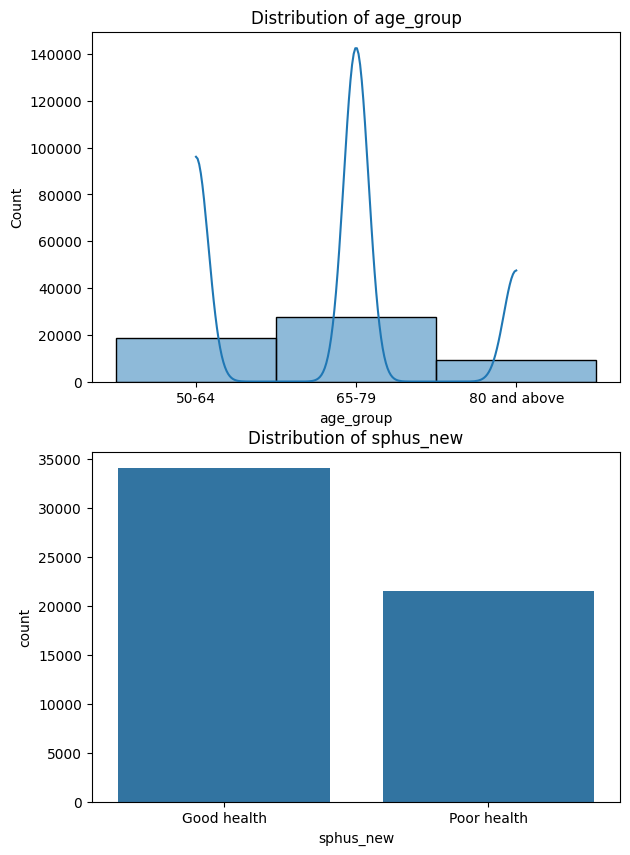

In [48]:
# Examine Data Shape and Types
print("Data Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

# Descriptive Statistics
print("\nDescriptive Statistics:\n", df.describe(include='all'))

# Visualize Variable Distributions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# Histograms for numerical features
# Changed 'age-group' to 'age_group'
for i, col in enumerate(['age_group']):  # Only numerical features
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

# Target variable distribution
plt.subplot(2,2,3)
sns.countplot(x='sphus_new', data=df)
plt.title('Distribution of sphus_new')



# Missing Values Analysis
print("\nMissing Values Percentage:\n", df.isnull().sum() / len(df) * 100)

# Unique Value Counts
for col in df.columns:
    print(f"\nUnique values and counts for {col}:\n{df[col].value_counts()}")



## Data exploration




Explore the data in `model_df` by checking its shape, data types, missing values, and distributions of key variables, and calculate the correlation matrix for numerical features.



In [49]:
# Check for missing values
print(df.isnull().sum())

# Check for duplicates
print(f"Number of duplicated rows: {df.duplicated().sum()}")

# Select relevant columns for modeling

model_df = df[['age_group', 'gender', 'sphus_new', 'chronicw9_new', 'adl2_new', 'iadl2_new', 'eurod_new', 'isced1997_r_new']]

# Display the first few rows and shape of the prepared DataFrame
display(model_df.head())
print(model_df.shape)

print(df.info())
print(df['age_group'].unique())
# Check if 'Unnamed: 0' column exists before dropping
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
# Convert 'age2022' to numeric, coercing errors to NaN
#df['age2022'] = pd.to_numeric(df['age2022'], errors='coerce')
print(df.info())

country            0
gender             0
age_int            0
partnerinhh        0
country_new        0
sphus_new          0
chronicw9_new      0
adl2_new           0
iadl2_new          0
eurod_new          0
isced1997_r_new    0
age_group          0
dtype: int64
Number of duplicated rows: 25225


,age_group,gender,sphus_new,chronicw9_new,adl2_new,iadl2_new,eurod_new,isced1997_r_new
0,50-64,Male,Good health,Chronic disease,No limitations,No limitations,Not depressed,Post-secondary education
1,65-79,Female,Good health,Chronic disease,No limitations,No limitations,Not depressed,Higher secondary education
2,50-64,Male,Poor health,Chronic disease,No limitations,No limitations,Not depressed,Higher secondary education
3,80 and above,Male,Good health,Chronic disease,Limited,Limited,Not depressed,Lower secondary education
4,80 and above,Female,Poor health,Chronic disease,No limitations,No limitations,Not depressed,Higher secondary education


(55492, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55492 entries, 0 to 55491
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   country          55492 non-null  object
 1   gender           55492 non-null  object
 2   age_int          55492 non-null  int64 
 3   partnerinhh      55492 non-null  object
 4   country_new      55492 non-null  object
 5   sphus_new        55492 non-null  object
 6   chronicw9_new    55492 non-null  object
 7   adl2_new         55492 non-null  object
 8   iadl2_new        55492 non-null  object
 9   eurod_new        55492 non-null  object
 10  isced1997_r_new  55492 non-null  object
 11  age_group        55492 non-null  object
dtypes: int64(1), object(11)
memory usage: 5.1+ MB
None
['50-64' '65-79' '80 and above']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55492 entries, 0 to 55491
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  --

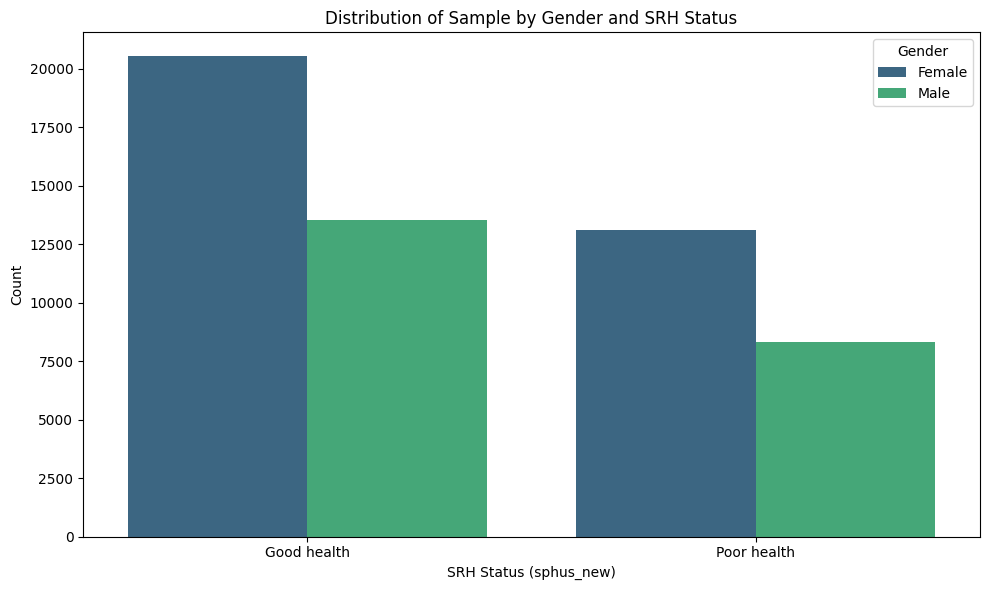

In [50]:
#bar chart of the Sample distribution by gender "gender" and SRH status 'sphus_new'

import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn
# Group by 'sphus_new' and 'gender' and count occurrences
srh_gender_counts = df.groupby(['sphus_new', 'gender']).size().reset_index(name='count')

# Create a grouped bar chart with 'sphus_new' on the x-axis
plt.figure(figsize=(10, 6))
sns.barplot(data=srh_gender_counts, x='sphus_new', y='count', hue='gender', palette='viridis')
plt.title('Distribution of Sample by Gender and SRH Status')
plt.xlabel('SRH Status (sphus_new)')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [51]:
#student t test and chi square test among all the variables

import pandas as pd
from scipy import stats
from scipy.stats import chi2_contingency



relevant_cols = ['sphus_new', 'gender','chronicw9_new', 'adl2_new', 'iadl2_new', 'eurod_new', 'isced1997_r_new']
analysis_df = df[relevant_cols].copy()

# Convert categorical variables to numeric for t-tests (if applicable)
# Identify which columns are categorical and which are potentially numeric/ordinal
# Assuming 'sphus_new', 'chronicw9_new', 'adl2_new', 'iadl2_new', 'eurod_new', 'isced1997_r_new' are categorical
# We need to decide how to treat them for statistical tests.
# For simplicity, let's assume 'sphus_new' is the target binary variable for t-tests (e.g., Good vs Poor health)
# And other variables are features.

# Example: Perform t-tests comparing features between 'Good health' and 'Poor health' groups
# This is only appropriate if the features are numerical and the assumptions for t-tests are met.
# If the features are categorical, chi-square tests are more appropriate.

# Let's first identify categorical and numerical columns among the relevant ones.
# Based on the column names, they seem to be mostly categorical.
# We will perform chi-square tests for independence between 'sphus_new' and the other categorical features.
# If any feature was truly continuous and normally distributed, we would consider t-tests.

print("--- Chi-Square Tests of Independence ---")
# Perform Chi-Square tests for independence between 'sphus_new' and other categorical variables
categorical_features = ['chronicw9_new', 'adl2_new', 'iadl2_new', 'eurod_new', 'isced1997_r_new']

for feature in categorical_features:
  print(f"\nTesting independence between 'sphus_new' and '{feature}':")
  # Create a contingency table
  contingency_table = pd.crosstab(analysis_df['sphus_new'], analysis_df[feature])
  print("Contingency Table:")
  display(contingency_table)

  # Perform the Chi-Square test
  chi2, p, dof, expected = chi2_contingency(contingency_table)

  print(f"Chi-Square Statistic: {chi2:.4f}")
  print(f"P-value: {p:.4f}")
  print(f"Degrees of Freedom: {dof}")
  # print("Expected Frequencies:")
  # print(expected)

  # Interpret the result
  alpha = 0.05
  if p < alpha:
    print(f"Result: Reject the null hypothesis. There is a statistically significant association between 'sphus_new' and '{feature}'.")
  else:
    print(f"Result: Fail to reject the null hypothesis. There is no statistically significant association between 'sphus_new' and '{feature}'.")







# Since the features are categorical, we primarily rely on the chi-square test results.
# If you need to perform t-tests, you would need to carefully select appropriate numerical variables
# and potentially transform categorical variables (e.g., ordinal encoding or creating dummy variables
# if meaningful for a numerical test, though chi-square is generally preferred for independence of categories).

--- Chi-Square Tests of Independence ---

Testing independence between 'sphus_new' and 'chronicw9_new':
Contingency Table:


chronicw9_new,Chronic disease,No chronic disease
sphus_new,,
Good health,23754,10281
Poor health,20394,1063


Chi-Square Statistic: 5158.7528
P-value: 0.0000
Degrees of Freedom: 1
Result: Reject the null hypothesis. There is a statistically significant association between 'sphus_new' and 'chronicw9_new'.

Testing independence between 'sphus_new' and 'adl2_new':
Contingency Table:


adl2_new,Limited,No limitations
sphus_new,,
Good health,1126,32909
Poor health,4416,17041


Chi-Square Statistic: 4365.5027
P-value: 0.0000
Degrees of Freedom: 1
Result: Reject the null hypothesis. There is a statistically significant association between 'sphus_new' and 'adl2_new'.

Testing independence between 'sphus_new' and 'iadl2_new':
Contingency Table:


...

Chi-Square Statistic: 6479.7223
P-value: 0.0000
Degrees of Freedom: 1
Result: Reject the null hypothesis. There is a statistically significant association between 'sphus_new' and 'iadl2_new'.

Testing independence between 'sphus_new' and 'eurod_new':
Contingency Table:


eurod_new,Depressed,Not depressed
sphus_new,,
Good health,5345,28690
Poor health,9989,11468


Chi-Square Statistic: 6261.4805
P-value: 0.0000
Degrees of Freedom: 1
Result: Reject the null hypothesis. There is a statistically significant association between 'sphus_new' and 'eurod_new'.

Testing independence between 'sphus_new' and 'isced1997_r_new':
Contingency Table:


isced1997_r_new,Higher secondary education,Lower secondary education,Post-secondary education
sphus_new,,,
Good health,16033,8458,9544
Poor health,9613,7804,4040


Chi-Square Statistic: 1067.4234
P-value: 0.0000
Degrees of Freedom: 2
Result: Reject the null hypothesis. There is a statistically significant association between 'sphus_new' and 'isced1997_r_new'.


In [52]:
# check if Differences between each variable are statistically significant

import pandas as pd
from scipy import stats
from scipy.stats import chi2_contingency

# Interpretation of Chi-Square Test Results:
# For each categorical feature, the Chi-Square test was performed to assess if there is a
# statistically significant association between that feature and 'sphus_new'.
#
# - If the P-value is less than the significance level (commonly 0.05), we reject the null hypothesis
#   of independence. This means there is a statistically significant relationship between the two variables.
#   The differences in the distribution of 'sphus_new' across the categories of the feature are unlikely
#   to be due to random chance.
# - If the P-value is greater than or equal to the significance level (0.05), we fail to reject the null
#   hypothesis. This suggests there is no statistically significant evidence of an association between
#   the two variables in the sample. The observed differences are likely due to random variation.
#
# Based on the output of the preceding Chi-Square tests:
# - For each feature ('chronicw9_new', 'adl2_new', 'iadl2_new', 'eurod_new', 'isced1997_r_new'),
#   examine the printed P-value.
# - If P < 0.05, the differences in 'sphus_new' distribution across the categories of that feature
#   are statistically significant.
# - If P >= 0.05, the differences are not statistically significant.



if 'analysis_df' not in globals() or 'categorical_features' not in globals():
    print("Required variables 'analysis_df' or 'categorical_features' not found. Please run the preceding cells.")
else:
    print("\nSummary of Statistical Significance:")


    # To make this block directly executable and provide a summary based on the *calculated* p-values:
    # (This requires re-calculating the p-values or accessing them if they were stored)

    # Let's recalculate just the p-values for the summary:
    p_values = {}
    for feature in categorical_features:
      contingency_table = pd.crosstab(analysis_df['sphus_new'], analysis_df[feature])
      chi2, p, dof, expected = chi2_contingency(contingency_table)
      p_values[feature] = p

    print("\nConcise Summary of Statistical Significance (based on Chi-Square p-values):")
    alpha = 0.05
    for feature, p_value in p_values.items():
      if p_value < alpha:
        print(f"- Association between 'sphus_new' and '{feature}' is statistically significant (p={p_value:.4f}).")
      else:
        print(f"- Association between 'sphus_new' and '{feature}' is not statistically significant (p={p_value:.4f}).")


Summary of Statistical Significance:

Concise Summary of Statistical Significance (based on Chi-Square p-values):
- Association between 'sphus_new' and 'chronicw9_new' is statistically significant (p=0.0000).
- Association between 'sphus_new' and 'adl2_new' is statistically significant (p=0.0000).
- Association between 'sphus_new' and 'iadl2_new' is statistically significant (p=0.0000).
- Association between 'sphus_new' and 'eurod_new' is statistically significant (p=0.0000).
- Association between 'sphus_new' and 'isced1997_r_new' is statistically significant (p=0.0000).


In [53]:
# divide the data into two using gender categories "male" and "female" and save the data in google drive

# Filter data by gender
male_df = df[df['gender'] == 'Male'].copy()
female_df = df[df['gender'] == 'Female'].copy()

# Define paths to save in Google Drive
male_file_path = '/content/drive/My Drive/data_male.csv'
female_file_path = '/content/drive/My Drive/data_female.csv'

# Save the filtered dataframes to CSV in Google Drive
male_df.to_csv(male_file_path, index=False)
female_df.to_csv(female_file_path, index=False)

print(f"Male data saved to: {male_file_path}")
print(f"Female data saved to: {female_file_path}")

Male data saved to: /content/drive/My Drive/data_male.csv
Female data saved to: /content/drive/My Drive/data_female.csv


## Data preparation

Prepare the data for model training and converting categorical variables to numerical representations.



Convert categorical features to numerical representations using one-hot encoding and handle the target variable appropriately.  Then, verify the data types of all columns in the resulting DataFrame.



In [54]:
import pandas as pd

# Convert categorical features to numerical using one-hot encoding
df_encoded = pd.get_dummies(model_df, drop_first=True)

# Verify data types
print(df_encoded.dtypes)

display(df_encoded.head())

age_group_65-79                              bool
age_group_80 and above                       bool
gender_Male                                  bool
sphus_new_Poor health                        bool
chronicw9_new_No chronic disease             bool
adl2_new_No limitations                      bool
iadl2_new_No limitations                     bool
eurod_new_Not depressed                      bool
isced1997_r_new_Lower secondary education    bool
isced1997_r_new_Post-secondary education     bool
dtype: object


,age_group_65-79,age_group_80 and above,gender_Male,sphus_new_Poor health,chronicw9_new_No chronic disease,adl2_new_No limitations,iadl2_new_No limitations,eurod_new_Not depressed,isced1997_r_new_Lower secondary education,isced1997_r_new_Post-secondary education
0,False,False,True,False,False,True,True,True,False,True
1,True,False,False,False,False,True,True,True,False,False
2,False,False,True,True,False,True,True,True,False,False
3,False,True,True,False,False,False,False,True,True,False
4,False,True,False,True,False,True,True,True,False,False


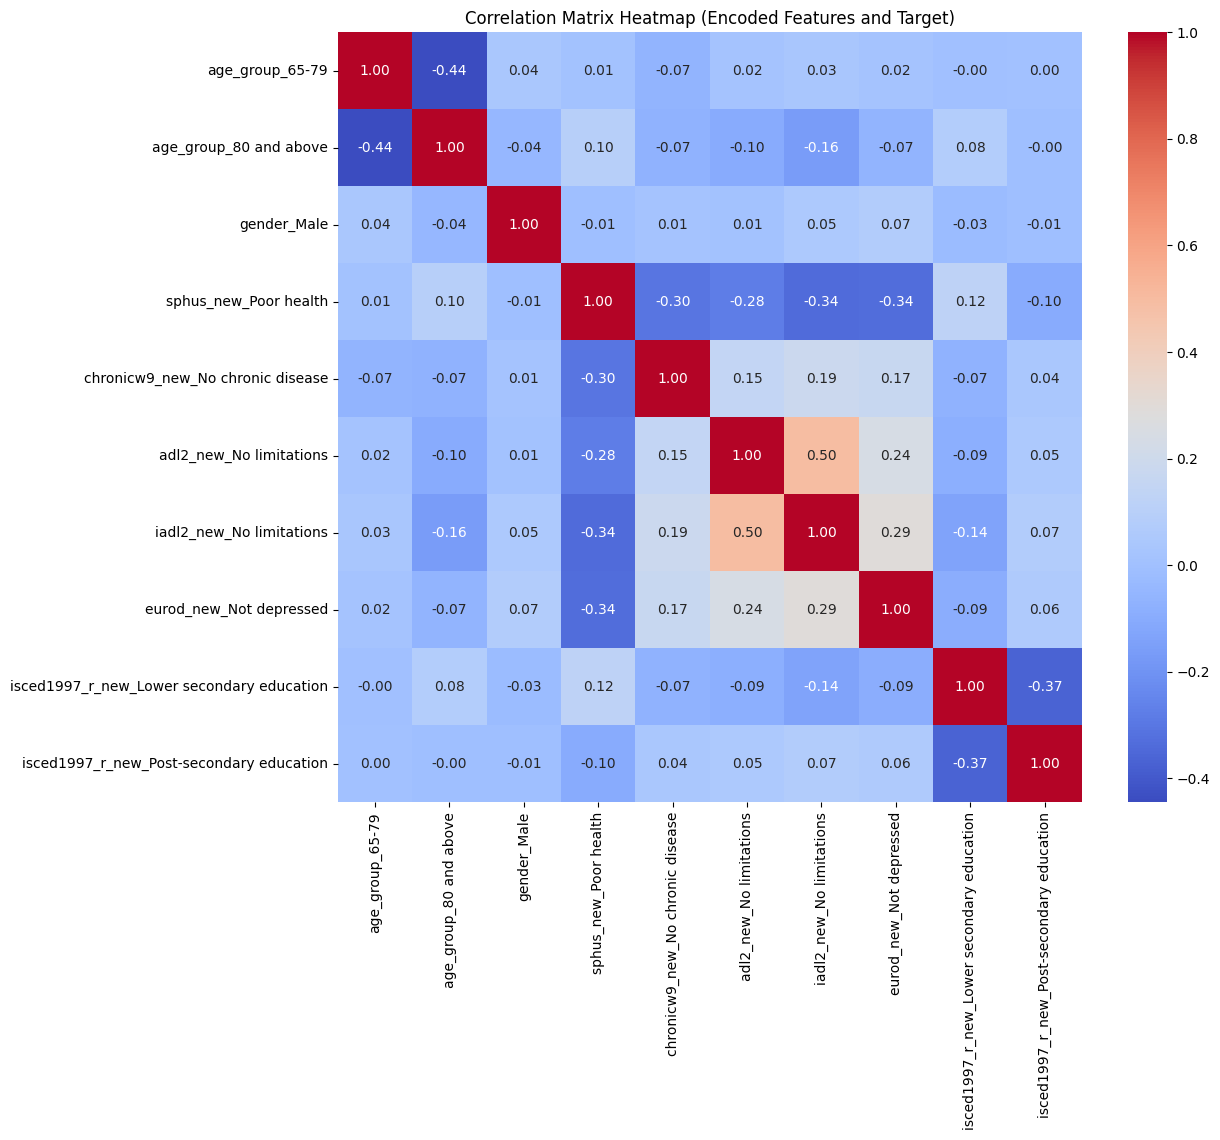


Correlation with target variable ('sphus_new_Poor health'):
sphus_new_Poor health                        1.000000
isced1997_r_new_Lower secondary education    0.123250
age_group_80 and above                       0.095701
age_group_65-79                              0.009197
gender_Male                                 -0.008448
isced1997_r_new_Post-secondary education    -0.104353
adl2_new_No limitations                     -0.280542
chronicw9_new_No chronic disease            -0.304946
eurod_new_Not depressed                     -0.335952
iadl2_new_No limitations                    -0.341763
Name: sphus_new_Poor health, dtype: float64


In [55]:
# we tested correlations among the all variable

import matplotlib.pyplot as plt

# Since all relevant columns for modeling in `model_df` are categorical after the initial exploration,
# calculating a standard Pearson correlation matrix for them isn't appropriate without
# first encoding them. The previous code block handles the encoding.

# After one-hot encoding,  can calculate the correlation matrix on the encoded DataFrame.
# This will show the correlation between the different categories of your original features
# and the target variable.

# Calculate the correlation matrix on the one-hot encoded DataFrame
correlation_matrix_encoded = df_encoded.corr()

# Display the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_encoded, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap (Encoded Features and Target)')
plt.show()

# can also look specifically at correlations with the target variable
# Assuming 'sphus_new_Poor health' is the encoded target variable after one-hot encoding
# (This needs to be confirmed based on the actual column names after encoding)
# If 'sphus_new' had other categories, the column name will reflect the category that was NOT dropped.
# Let's assume 'Good health' was dropped and 'Poor health' remains.
# Adjust the column name below if your target column after encoding is different.

if 'sphus_new_Poor health' in correlation_matrix_encoded.columns:
    correlation_with_target = correlation_matrix_encoded['sphus_new_Poor health'].sort_values(ascending=False)
    print("\nCorrelation with target variable ('sphus_new_Poor health'):")
    print(correlation_with_target)
else:
    print("\nTarget variable column after encoding not found. Please check column names in df_encoded.")
    print("Columns in df_encoded:", df_encoded.columns.tolist())

## Data splitting


Split the prepared data into training and testing sets.


In [56]:
#Split the data into training and testing sets

import numpy as np

# Assuming 'sphus_new' is your target variable and df_encoded is your prepared DataFrame
y = df_encoded['sphus_new_Poor health'].values  # Target variable
X = df_encoded.drop('sphus_new_Poor health', axis=1).values  # Features

# Determine the number of samples in each class
unique_classes, class_counts = np.unique(y, return_counts=True)
class_counts_dict = dict(zip(unique_classes, class_counts))

# Calculate the split point for each class based on a desired test size (e.g., 0.2)
test_size = 0.2
split_points = {c: int(count * (1 - test_size)) for c, count in class_counts_dict.items()}

# Create empty lists for the training and testing sets
X_train, X_test, y_train, y_test = [], [], [], []

# Iterate through each class
for class_val in unique_classes:
    class_indices = np.where(y == class_val)[0]
    # Split the indices of each class at the calculated split point
    train_indices = class_indices[:split_points[class_val]]
    test_indices = class_indices[split_points[class_val]:]

    # Append the samples to the training and testing sets
    X_train.extend(X[train_indices])
    X_test.extend(X[test_indices])
    y_train.extend(y[train_indices])
    y_test.extend(y[test_indices])

# Convert lists to NumPy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (44393, 9)
y_train shape: (44393,)
X_test shape: (11099, 9)
y_test shape: (11099,)


## Model training

Train six different classification models on the prepared training data.


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost') # Suppress XGBoost warning

# Instantiate the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver='liblinear'),  # Increased max_iter
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(kernel='linear', probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

# Train the models
for name, model in models.items():
    model.fit(X_train, y_train)

# The trained models are now stored in the 'models' dictionary

## Model evaluation

Evaluate the performance of the trained models using accuracy, sensitivity, specificity, F1-score, and precision.


,Accuracy,Precision,Sensitivity,Specificity,F1-score,AUROC,AUPRC
Model,,,,,,,
Logistic Regression,0.741328,0.709525,0.560578,0.855296,0.626318,0.795485,0.712883
Random Forest,0.741058,0.711768,0.555219,0.858234,0.623822,0.787414,0.701469
SVM,0.726822,0.723563,0.475070,0.885559,0.573558,0.785610,0.705847
XGBoost,0.740968,0.711052,0.556151,0.857500,0.624134,0.787841,0.701313
Naive Bayes,0.741869,0.709791,0.562442,0.855002,0.627584,0.795130,0.707016
K-Nearest Neighbors,0.614380,0.714286,0.004660,0.998825,0.009259,0.505254,0.391273


<Figure size 1200x600 with 0 Axes>

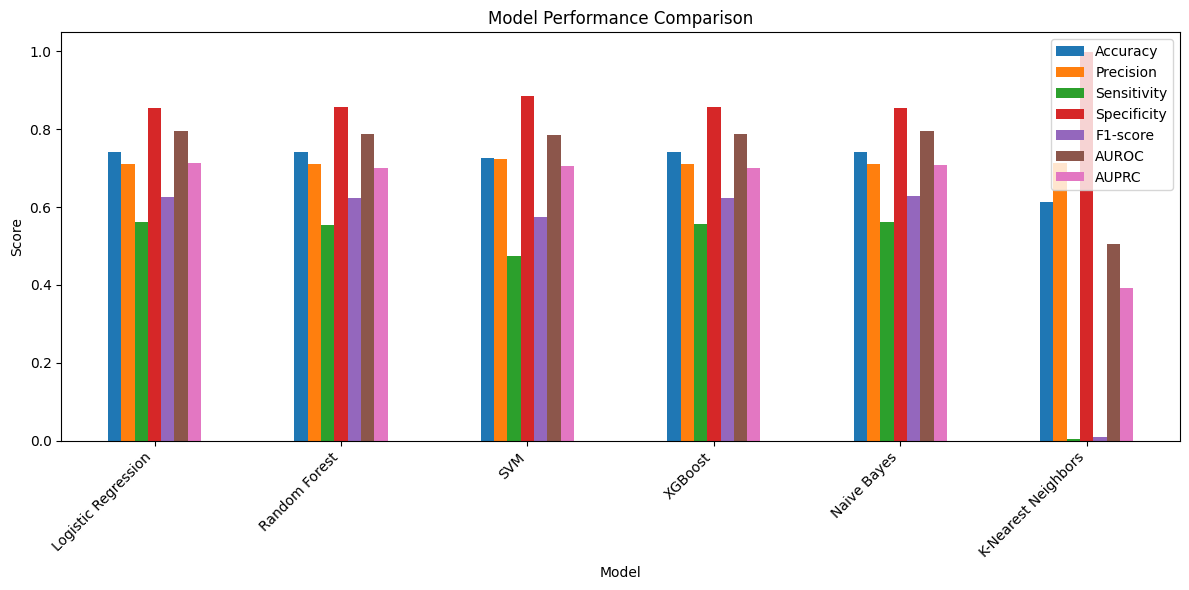

rf_importance_df not found. Skipping Random Forest feature importance plot.
xgb_importance_df not found. Skipping XGBoost feature importance plot.


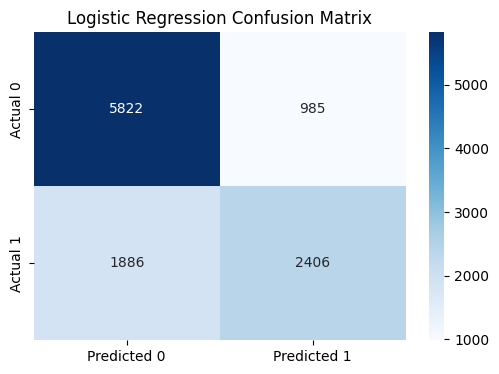

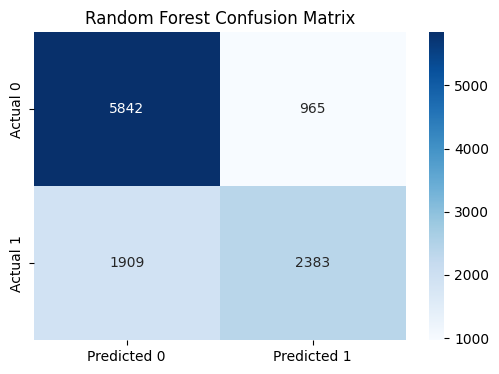

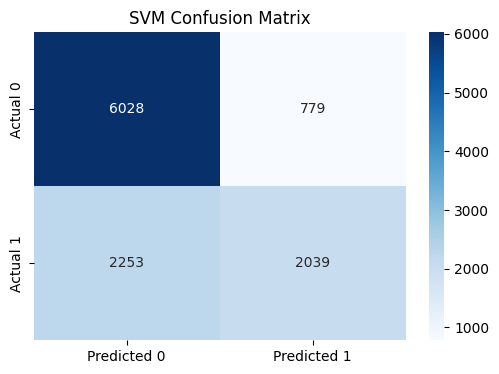

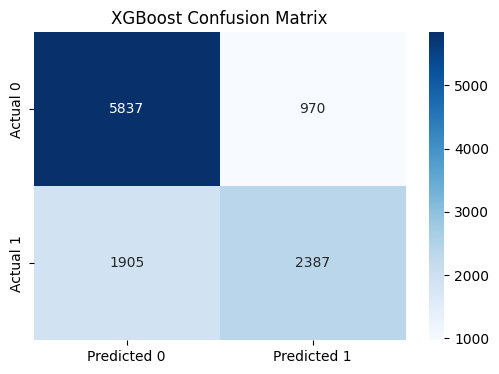

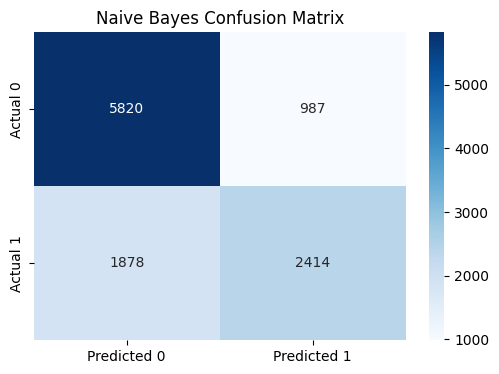

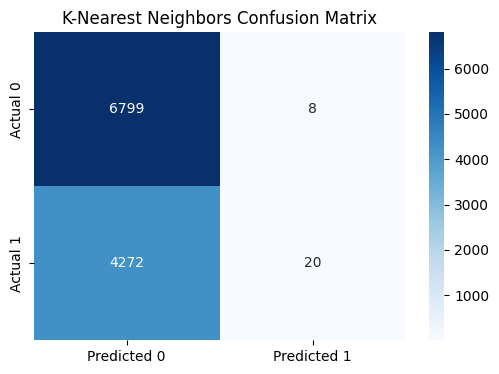

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
import pandas as pd
from IPython.display import display

# Calculate evaluation metrics for all models
results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = None
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    # precision_score, recall_score, f1_score can fail if no positive predictions or true positives exist.
    # zero_division=0 handles this by returning 0 instead of raising an error.
    precision = precision_score(y_test, y_pred, zero_division=0)
    sensitivity = recall_score(y_test, y_pred, zero_division=0)
    specificity = recall_score(y_test, y_pred, pos_label=0, zero_division=0) # Recall for negative class
    f1 = f1_score(y_test, y_pred, zero_division=0)

    auroc = float('nan')
    auprc = float('nan')
    if y_prob is not None and len(np.unique(y_test)) == 2: # Ensure both classes are present for AUROC/AUPRC
        try:
            auroc = roc_auc_score(y_test, y_prob)
            auprc = average_precision_score(y_test, y_prob)
        except ValueError:
            pass # Keep as NaN if calculation fails (e.g., single class in y_test after all)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'F1-score': f1,
        'AUROC': auroc,
        'AUPRC': auprc
    })

all_metrics_df = pd.DataFrame(results).set_index('Model')
display(all_metrics_df)

# Model Performance Comparison
plt.figure(figsize=(12, 6))
# Use all_metrics_df instead of eval_df
all_metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Feature Importance Visualization (Random Forest)
# Ensure rf_importance_df is defined and used correctly
if 'rf_importance_df' in globals():
    plt.figure(figsize=(8, 6))
    plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'], color='skyblue')
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("Random Forest Feature Importance")
    plt.tight_layout()
    plt.show()
else:
    print("rf_importance_df not found. Skipping Random Forest feature importance plot.")


# Feature Importance Visualization (XGBoost)
# Ensure xgb_importance_df is defined and used correctly
if 'xgb_importance_df' in globals():
    plt.figure(figsize=(8, 6))
    plt.barh(xgb_importance_df['Feature'], xgb_importance_df['Importance'], color='lightcoral')
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title("XGBoost Feature Importance")
    plt.tight_layout()
    plt.show()
else:
    print("xgb_importance_df not found. Skipping XGBoost feature importance plot.")


# Confusion Matrices
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f"{name} Confusion Matrix")
    plt.show()


Matthews Correlation Coefficient for each model:


,MCC
Logistic Regression,0.439678
Random Forest,0.438695
SVM,0.403512
XGBoost,0.438570
Naive Bayes,0.440975
K-Nearest Neighbors,0.033829


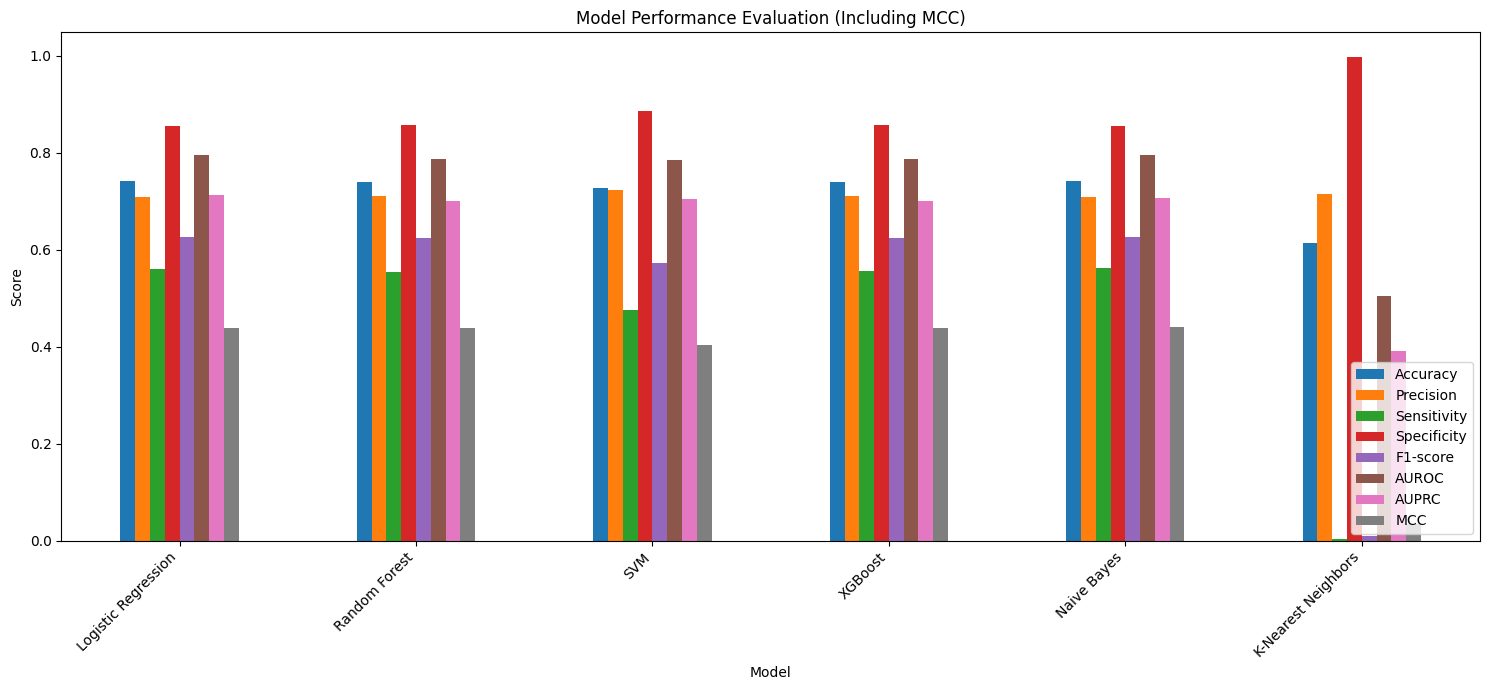

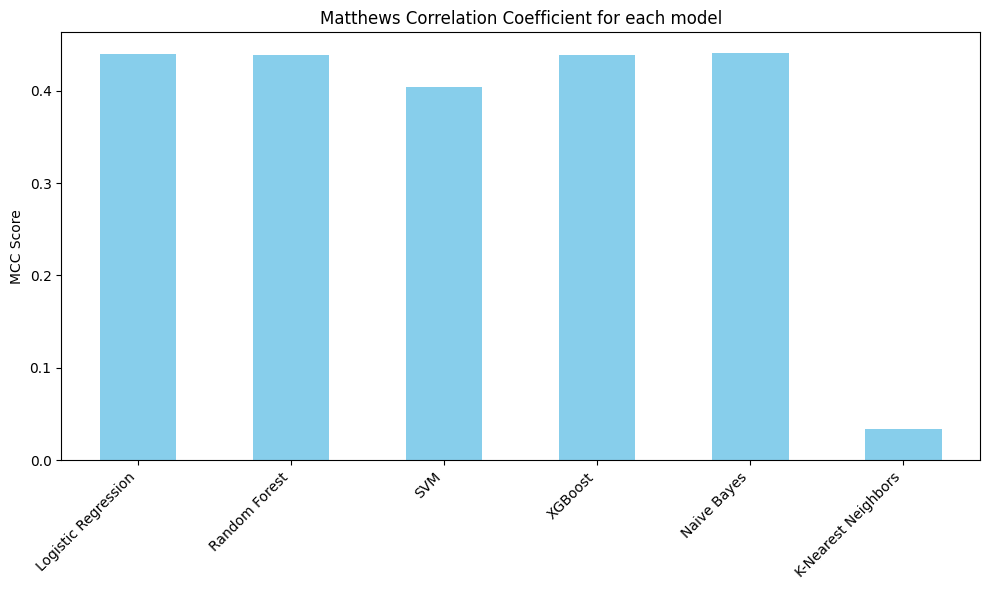

In [59]:
#  calculates the Matthews correlation coefficient and make a plot for all models

import pandas as pd
import matplotlib.pyplot as plt
from sklearn import metrics # Import the metrics module

# Calculate and print the Matthews correlation coefficient for each model
mcc_metrics = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    mcc = metrics.matthews_corrcoef(y_test, y_pred)
    mcc_metrics[name] = mcc

mcc_df = pd.DataFrame.from_dict(mcc_metrics, orient='index', columns=['MCC'])
print("\nMatthews Correlation Coefficient for each model:")
display(mcc_df)

# Combine MCC with other metrics for plotting
# Use all_metrics_df instead of eval_df
combined_eval_df = all_metrics_df.copy()
combined_eval_df['MCC'] = mcc_df['MCC']

# Plotting all evaluation metrics including MCC
combined_eval_df.plot(kind='bar', figsize=(15, 7))
plt.title('Model Performance Evaluation (Including MCC)')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Plotting only MCC
plt.figure(figsize=(10, 6))
mcc_df['MCC'].plot(kind='bar', color='skyblue')
plt.title('Matthews Correlation Coefficient for each model')
plt.ylabel('MCC Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Using full dataset (X_all, y_all) for cross-validation within grid_to_evaluate_models.
Evaluating models with folds ranging from 2 to 8...

Processing Logistic Regression...
  Using 2 folds...
  Using 3 folds...
  Using 4 folds...
  Using 5 folds...
  Using 6 folds...
  Using 7 folds...
  Using 8 folds...

Processing Random Forest...
  Using 2 folds...
  Using 3 folds...
  Using 4 folds...
  Using 5 folds...
  Using 6 folds...
  Using 7 folds...
  Using 8 folds...

Processing XGBoost...
  Using 2 folds...
  Using 3 folds...
  Using 4 folds...
  Using 5 folds...
  Using 6 folds...
  Using 7 folds...
  Using 8 folds...

Processing SVM...
  Using 2 folds...
  Using 3 folds...
  Using 4 folds...
  Using 5 folds...
  Using 6 folds...
  Using 7 folds...
  Using 8 folds...

Processing Naive Bayes...
  Using 2 folds...
  Using 3 folds...
  Using 4 folds...
  Using 5 folds...
  Using 6 folds...
  Using 7 folds...
  Using 8 folds...

Processing K-Nearest Neighbors...
  Using 2 folds...
  Using 3

,Number of Folds (CV),Balanced Accuracy,Matthews Correlation Coefficient (MCC)
0,2,0.700882,0.425134
1,3,0.700838,0.425113
2,4,0.701275,0.425354
3,5,0.701087,0.425139
4,6,0.700798,0.424845
5,7,0.701269,0.425320
6,8,0.700881,0.424822



--- Random Forest ---


,Number of Folds (CV),Balanced Accuracy,Matthews Correlation Coefficient (MCC)
0,2,0.701211,0.424953
1,3,0.699862,0.424063
2,4,0.699420,0.423899
3,5,0.698706,0.423142
4,6,0.699651,0.423809
5,7,0.699108,0.423250
6,8,0.699110,0.423443



--- XGBoost ---


...

,Number of Folds (CV),Balanced Accuracy,Matthews Correlation Coefficient (MCC)
0,2,0.702061,0.423222
1,3,0.701530,0.424690
2,4,0.701297,0.424267
3,5,0.701659,0.424667
4,6,0.701719,0.424698
5,7,0.701992,0.425173
6,8,0.701843,0.424616



--- Naive Bayes ---


,Number of Folds (CV),Balanced Accuracy,Matthews Correlation Coefficient (MCC)
0,2,0.701486,0.424276
1,3,0.701486,0.424276
2,4,0.701486,0.424276
3,5,0.701486,0.424276
4,6,0.701486,0.424276
5,7,0.701486,0.424276
6,8,0.701486,0.424276



--- K-Nearest Neighbors ---


,Number of Folds (CV),Balanced Accuracy,Matthews Correlation Coefficient (MCC)
0,2,0.658019,0.367409
1,3,0.658875,0.350145
2,4,0.664259,0.365699
3,5,0.664145,0.360318
4,6,0.662928,0.353002
5,7,0.663829,0.361658
6,8,0.667634,0.365674


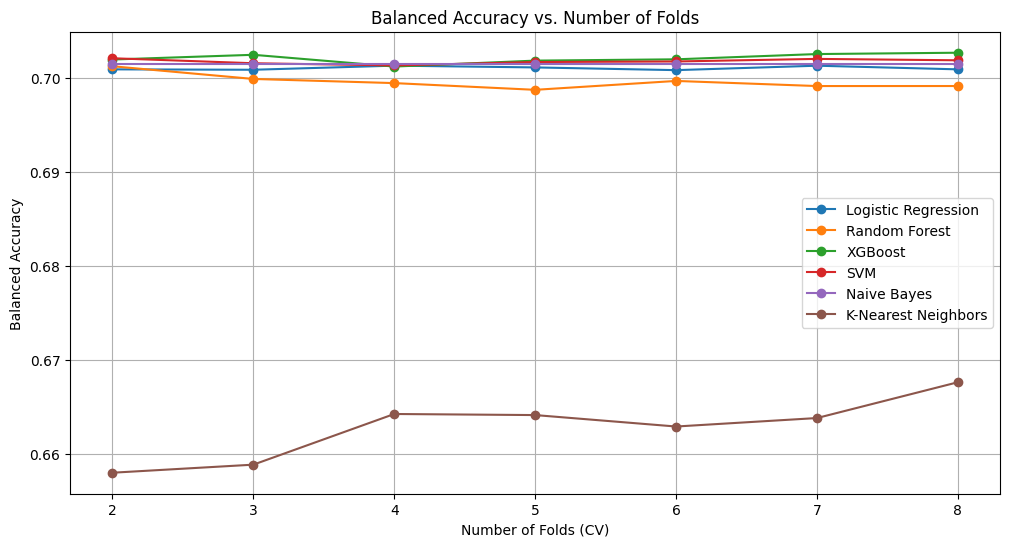

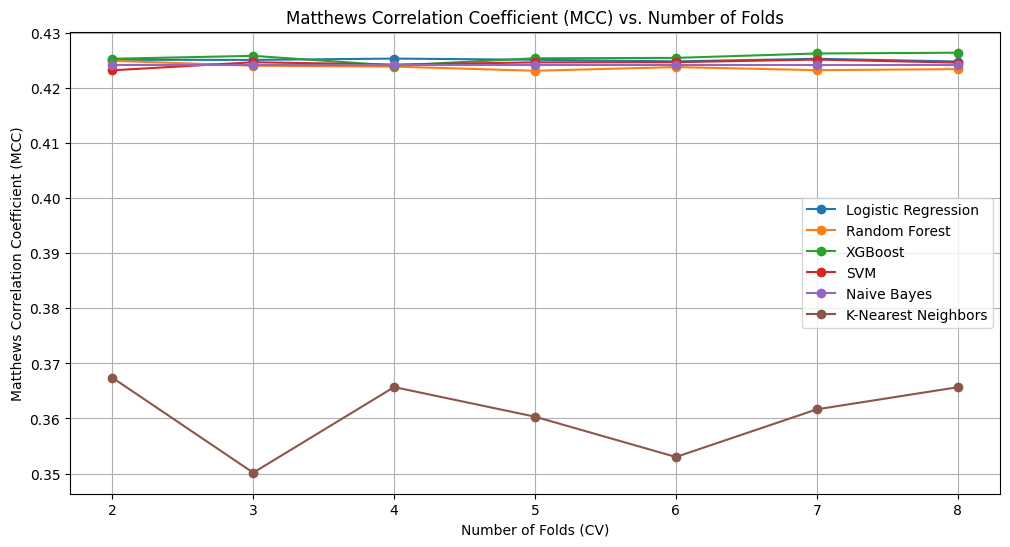

In [60]:
#multiple hyperparameters simultaneously, computes accuracy, and also calculates the Matthews correlation coefficient. The hyperparameters will be tuned using Grid Search procedure with folds varying from 2 to 8. The performance of each model will later be plotted as a function of the number of folds.

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_predict, GridSearchCV, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost') # Suppress XGBoost warning

def grid_to_evaluate_models(X, y, cv_range=(2, 9)):
    """
    Performs Grid Search with varying folds, computes accuracy and MCC.

    Args:
        X (np.ndarray or pd.DataFrame): Feature data.
        y (np.ndarray or pd.Series): Target variable.
        cv_range (tuple): Range of folds (min, max + 1) to iterate through.

    Returns:
        dict: A dictionary where keys are model names and values are dictionaries
              containing lists for 'cv', 'mcc', and 'acc', and the 'best_estimator'.
    """
    # Define parameter grids (can be expanded) - using previously defined grids
    param_grid_lr = {'C': [0.1, 1], 'solver': ['liblinear']} # Reduced grid for speed
    param_grid_rf = {'n_estimators': [50, 100], 'max_depth': [None, 5]} # Reduced grid for speed
    param_grid_xgb = {'n_estimators': [50, 100], 'learning_rate': [0.1], 'max_depth': [3, 5]} # Reduced grid for speed
    param_grid_svc = {'C': [1], 'kernel': ['rbf'], 'gamma': ['scale']} # Reduced grid for speed
    param_grid_knn = {'n_neighbors': [5, 7], 'weights': ['uniform']} # Reduced grid for speed
    param_grid_nb = {} # Gaussian Naive Bayes has no hyperparameters to tune

    # Models and their parameter grids
    models_and_grids = {
        "Logistic Regression": (LogisticRegression(max_iter=1000), param_grid_lr),
        "Random Forest": (RandomForestClassifier(random_state=42), param_grid_rf),
        "XGBoost": (XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), param_grid_xgb),
        "SVM": (SVC(probability=True, random_state=42), param_grid_svc),
        "Naive Bayes": (GaussianNB(), param_grid_nb),
        "K-Nearest Neighbors": (KNeighborsClassifier(), param_grid_knn)
    }

    all_models_performance = {}

    print(f"Evaluating models with folds ranging from {cv_range[0]} to {cv_range[1]-1}...")

    for name, (model, param_grid) in models_and_grids.items():
        print(f"\nProcessing {name}...")
        all_models_performance[name] = {
            "cv": [],
            "mcc": [],
            "acc": [],
            "best_estimator": None # Store the best estimator from the last fold
        }

        # Iterate through different numbers of folds
        for n_folds in range(cv_range[0], cv_range[1]):
            print(f"  Using {n_folds} folds...")
            all_models_performance[name]["cv"].append(n_folds)

            # Define cross-validation strategy
            kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)



            # Create a GridSearchCV object for the current model and parameter grid
            grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=kf, scoring='accuracy', n_jobs=-1, verbose=0) # verbose=0 to reduce output

            # Fit the GridSearchCV on the entire data to find best parameters for this n_folds
            grid_search.fit(X, y)

            # Get the best estimator found by Grid Search for this number of folds
            best_estimator = grid_search.best_estimator_

            # Store the best estimator found for the *last* number of folds
            if n_folds == cv_range[1] - 1:
                 all_models_performance[name]["best_estimator"] = best_estimator


            # Perform cross-prediction with the best estimator for this number of folds
            y_pred_cv = cross_val_predict(best_estimator, X, y, cv=kf)

            # Compute balanced accuracy and Matthews Correlation Coefficient
            balanced_acc = balanced_accuracy_score(y, y_pred_cv)
            mcc = matthews_corrcoef(y, y_pred_cv)

            all_models_performance[name]["acc"].append(balanced_acc)
            all_models_performance[name]["mcc"].append(mcc)

            # print(f"    Balanced Accuracy: {balanced_acc:.4f}")
            # print(f"    MCC: {mcc:.4f}")


    return all_models_performance

# Ensure X and y are defined from the previous data splitting cell
# Assuming 'sphus_new_Poor health' is your target variable name in df_encoded
target_column_name = 'sphus_new_Poor health'
if 'df_encoded' in globals() and target_column_name in df_encoded.columns:
    y_all = df_encoded[target_column_name].values  # Target variable from full dataset
    X_all = df_encoded.drop(target_column_name, axis=1).values  # Features from full dataset
    print("Using full dataset (X_all, y_all) for cross-validation within grid_to_evaluate_models.")
else:
    print("df_encoded or target column not found. Please ensure previous data loading and preparation steps were successful.")
    # As a fallback, use X and y from the train/test split, though cross-validation
    # is typically done on the full dataset.
    # X_all = np.concatenate((X_train, X_test), axis=0)
    # y_all = np.concatenate((y_train, y_test), axis=0)
    # print("Using concatenated train/test data (X, y) for cross-validation.")
    # Exit or handle the error if data is not available
    # raise SystemExit("Data not available to proceed with model evaluation.")


# Run the evaluation function
if 'X_all' in globals() and 'y_all' in globals():
    cv_range_for_plotting = (2, 9) # Define cv_range here for plotting
    model_performance_results = grid_to_evaluate_models(X_all, y_all, cv_range=cv_range_for_plotting)

    # Print or display the results
    print("\nModel Performance Results across different folds:")
    for model_name, results in model_performance_results.items():
        print(f"\n--- {model_name} ---")
        results_df = pd.DataFrame({
            "Number of Folds (CV)": results["cv"],
            "Balanced Accuracy": results["acc"],
            "Matthews Correlation Coefficient (MCC)": results["mcc"]
        })
        display(results_df)
        # print("Best Estimator (from last fold):")
        # print(results["best_estimator"])


    # Plotting the performance metrics as a function of folds
    metrics_to_plot = ["Balanced Accuracy", "Matthews Correlation Coefficient (MCC)"]

    for metric_name in metrics_to_plot:
        plt.figure(figsize=(12, 6))
        for model_name, results in model_performance_results.items():
            # Ensure the metric exists in the results dictionary
            # Need to map the metric_name string to the key in the results dict ('acc' or 'mcc')
            result_key = 'acc' if metric_name == 'Balanced Accuracy' else 'mcc'
            if result_key in results:
                plt.plot(results["cv"], results[result_key], marker='o', label=model_name)

        plt.xlabel("Number of Folds (CV)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} vs. Number of Folds")
        plt.xticks(range(cv_range_for_plotting[0], cv_range_for_plotting[1])) # Ensure x-axis ticks are integers corresponding to folds
        plt.legend()
        plt.grid(True)
        plt.show()

else:
    print("Model evaluation could not proceed because data (X_all, y_all) is not available.")



In [61]:
# evaluate the model performance of all folds using accuracy, sensitivity, specificity, F1-score, AUROC, AUPRC and precision.

from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, average_precision_score
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier # Import XGBClassifier for type checking



# Ensure X_all and y_all are defined from the previous cell that runs grid_to_evaluate_models
# and model_performance_results is available

if 'X_all' in globals() and 'y_all' in globals() and 'model_performance_results' in globals():
    print("\nEvaluating model performance on each fold using the best estimator from the last fold:")

    all_folds_performance = {}

    for model_name, results in model_performance_results.items():
        best_estimator = results["best_estimator"]
        if best_estimator is None:
            print(f"Skipping {model_name}: No best estimator found.")
            continue

        print(f"\n--- Evaluating {model_name} ---")

        # Define the KFold strategy using the number of folds from the last run in grid_to_evaluate_models
        # Use the number of folds from the last iteration of the grid search loop
        n_folds = results["cv"][-1] if results["cv"] else 5 # Default to 5 if no cv folds were recorded
        print(f"Using {n_folds} folds for evaluation.")
        kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

        fold_metrics = []

        # Iterate through each fold
        for fold, (train_index, val_index) in enumerate(kf.split(X_all, y_all)):
            X_train_fold, X_val_fold = X_all[train_index], X_all[val_index]
            y_train_fold, y_val_fold = y_all[train_index], y_all[val_index]

            try:
                # Create a new instance of the best estimator to fit on the current fold's data
                model_instance = type(best_estimator)(**best_estimator.get_params())

                # Handle XGBoost eval_metric if it was removed by get_params
                if isinstance(model_instance, XGBClassifier) and 'eval_metric' not in model_instance.get_params():
                     model_instance.set_params(eval_metric='logloss')


                model_instance.fit(X_train_fold, y_train_fold)
                y_pred_fold = model_instance.predict(X_val_fold)

                # Calculate metrics for the current fold
                metrics_this_fold = {
                    "Fold": fold + 1,
                    "Accuracy": accuracy_score(y_val_fold, y_pred_fold),
                    "Precision": precision_score(y_val_fold, y_pred_fold, zero_division=0),
                    "Recall (Sensitivity)": recall_score(y_val_fold, y_pred_fold),
                    "F1-score": f1_score(y_val_fold, y_pred_fold),
                    # Specificity is recall for the negative class (assuming 0 is the negative class)
                    "Specificity": recall_score(y_val_fold, y_pred_fold, pos_label=0, zero_division=0)
                }

                # AUROC and AUPRC require probability estimates
                if hasattr(model_instance, 'predict_proba'):
                    y_pred_proba_fold = model_instance.predict_proba(X_val_fold)[:, 1]
                    try:
                        auroc_fold = roc_auc_score(y_val_fold, y_pred_proba_fold)
                    except ValueError: # Handles case where a class is missing in the fold
                         auroc_fold = np.nan
                         print(f"  Warning: AUROC could not be calculated for fold {fold + 1} due to missing class in validation set.")

                    try:
                         auprc_fold = average_precision_score(y_val_fold, y_pred_proba_fold)
                    except ValueError: # Handles case where a class is missing in the fold
                         auprc_fold = np.nan
                         print(f"  Warning: AUPRC could not be calculated for fold {fold + 1} due to missing class in validation set.")
                    metrics_this_fold["AUROC"] = auroc_fold
                    metrics_this_fold["AUPRC"] = auprc_fold


                else:
                     metrics_this_fold["AUROC"] = np.nan
                     metrics_this_fold["AUPRC"] = np.nan
                     if fold == 0: # Print warning only once per model
                          print(f"  Warning: Model {model_name} does not support predict_proba. AUROC and AUPRC will be NaN.")

                fold_metrics.append(metrics_this_fold)

            except Exception as e:
                print(f"  Error evaluating fold {fold + 1} for {model_name}: {e}")
                # Append a row with NaNs for this fold if evaluation fails
                fold_metrics.append({
                     "Fold": fold + 1,
                    "Accuracy": np.nan,
                    "Precision": np.nan,
                    "Recall (Sensitivity)": np.nan,
                    "F1-score": np.nan,
                    "Specificity": np.nan,
                    "AUROC": np.nan,
                    "AUPRC": np.nan
                })


        # Store the results for this model
        all_folds_performance[model_name] = pd.DataFrame(fold_metrics)

        # Display performance per fold
        print(f"Performance per fold for {model_name}:")
        display(all_folds_performance[model_name])

        # Display average performance across all folds
        print(f"\nAverage performance across {n_folds} folds for {model_name}:")
        display(all_folds_performance[model_name].mean().to_frame(name='Average Score'))

else:
    print("Required data (X_all, y_all) or model performance results not found. Please ensure preceding cells were run successfully.")


Evaluating model performance on each fold using the best estimator from the last fold:

--- Evaluating Logistic Regression ---
Using 8 folds for evaluation.
Performance per fold for Logistic Regression:


,Fold,Accuracy,Precision,Recall (Sensitivity),F1-score,Specificity,AUROC,AUPRC
0,1,0.738071,0.702576,0.559284,0.622794,0.850764,0.788028,0.707704
1,2,0.729999,0.691615,0.544370,0.609222,0.847004,0.773967,0.696596
2,3,0.742252,0.708683,0.565996,0.629353,0.853349,0.787508,0.710302
3,4,0.729278,0.691758,0.541185,0.607277,0.847908,0.775797,0.695266
4,5,0.728950,0.691683,0.539523,0.606200,0.848378,0.777797,0.695328
5,6,0.735294,0.696927,0.558166,0.619876,0.846968,0.785727,0.704119
6,7,0.725923,0.681712,0.546234,0.606500,0.839210,0.771955,0.690128
7,8,0.747693,0.725338,0.559284,0.631579,0.866479,0.796275,0.722171



Average performance across 8 folds for Logistic Regression:


,Average Score
Fold,4.500000
Accuracy,0.734682
Precision,0.698787
Recall (Sensitivity),0.551755
F1-score,0.616600
Specificity,0.850007
AUROC,0.782132
AUPRC,0.702702



--- Evaluating Random Forest ---
Using 8 folds for evaluation.
Performance per fold for Random Forest:


...

,Average Score
Fold,4.500000
Accuracy,0.734178
Precision,0.694925
Recall (Sensitivity),0.557255
F1-score,0.618501
Specificity,0.845718
AUROC,0.776628
AUPRC,0.690834



--- Evaluating K-Nearest Neighbors ---
Using 8 folds for evaluation.
Performance per fold for K-Nearest Neighbors:


,Fold,Accuracy,Precision,Recall (Sensitivity),F1-score,Specificity,AUROC,AUPRC
0,1,0.713853,0.703207,0.449664,0.548556,0.880376,0.736029,0.629523
1,2,0.695546,0.646756,0.468307,0.543253,0.838778,0.708646,0.596138
2,3,0.707655,0.641804,0.551827,0.593424,0.805875,0.731137,0.620623
3,4,0.711403,0.671192,0.497577,0.571490,0.846262,0.737029,0.624921
4,5,0.701701,0.656617,0.479120,0.553999,0.842031,0.724999,0.610125
5,6,0.717849,0.713612,0.451529,0.553094,0.885755,0.744172,0.629160
6,7,0.714533,0.713764,0.436987,0.542091,0.889516,0.738038,0.623276
7,8,0.717705,0.680100,0.509694,0.582694,0.848848,0.745589,0.626707



Average performance across 8 folds for K-Nearest Neighbors:


,Average Score
Fold,4.500000
Accuracy,0.710030
Precision,0.678381
Recall (Sensitivity),0.480588
F1-score,0.561075
Specificity,0.854680
AUROC,0.733205
AUPRC,0.620059



Generating AUPRC curves for each model (averaged across folds):
Using 8 folds to generate AUPRC data.
Generating AUPRC data for Logistic Regression...


<>:90: SyntaxWarning: invalid escape sequence '\p'
<>:99: SyntaxWarning: invalid escape sequence '\p'
<>:90: SyntaxWarning: invalid escape sequence '\p'
<>:99: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1705/2974942552.py:90: SyntaxWarning: invalid escape sequence '\p'
  label=f'{model_name} (Mean AUPRC = {mean_auprc:.2f} $\pm$ {std_auprc:.2f})',
/tmp/ipykernel_1705/2974942552.py:99: SyntaxWarning: invalid escape sequence '\p'
  label=f'$\pm$ 1 Std. Dev. ({model_name})') # Add model name to std dev label for clarity


Generating AUPRC data for Random Forest...
Generating AUPRC data for XGBoost...
Generating AUPRC data for SVM...
Generating AUPRC data for Naive Bayes...
Generating AUPRC data for K-Nearest Neighbors...


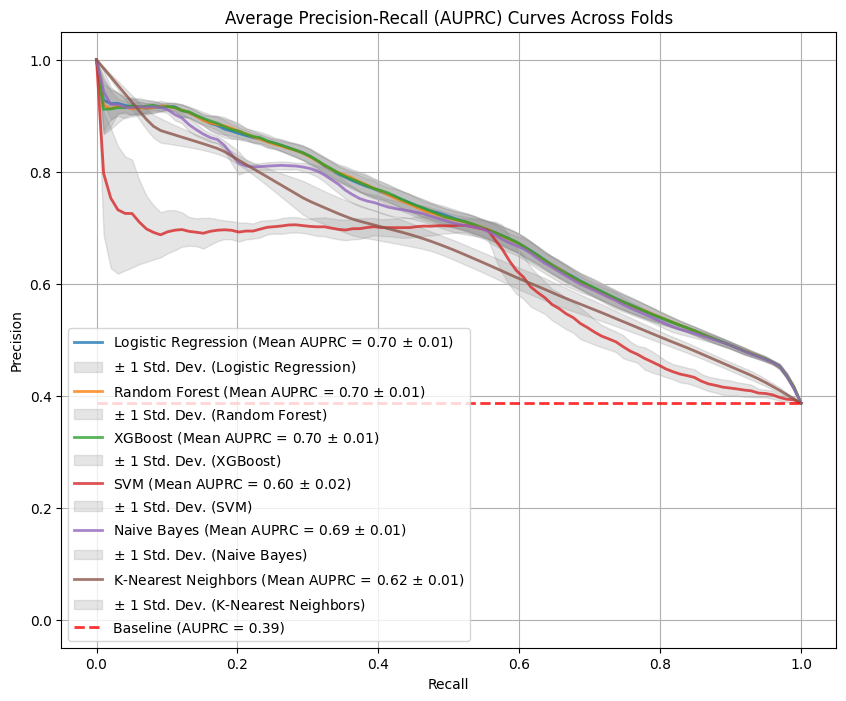

In [62]:
#generate a plot the average auprc curve metric   of all model in a single curve

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, auc, average_precision_score # Import necessary functions
from sklearn import metrics # Import the metrics module
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier # Import XGBClassifier for type checking
import matplotlib.ticker as mticker # Import mticker (if needed for plotting)

# Prepare data for plotting AUPRC curves across folds
# This requires re-running cross-validation and storing probability predictions for each fold

print("\nGenerating AUPRC curves for each model (averaged across folds):")

# Define the KFold strategy (using the same number of folds as before)
n_folds_for_auprc = model_performance_results[list(model_performance_results.keys())[0]]["cv"][-1] if model_performance_results and model_performance_results[list(model_performance_results.keys())[0]]["cv"] else 5
print(f"Using {n_folds_for_auprc} folds to generate AUPRC data.")
kf_auprc = StratifiedKFold(n_splits=n_folds_for_auprc, shuffle=True, random_state=42)

plt.figure(figsize=(10, 8))

# Calculate the baseline AUPRC (proportion of the positive class in the full dataset)
# Ensure y_all is available
baseline_auprc = np.sum(y_all) / len(y_all) if 'y_all' in globals() and len(y_all) > 0 else 0


# Iterate through each model
if 'model_performance_results' in globals() and 'X_all' in globals() and 'y_all' in globals():
    for model_name, results in model_performance_results.items():
        best_estimator = results.get("best_estimator")
        if best_estimator is None or not hasattr(best_estimator, 'predict_proba'):
            print(f"Skipping AUPRC plot for {model_name}: No best estimator or does not support predict_proba.")
            continue

        print(f"Generating AUPRC data for {model_name}...")

        # Lists to store Precision, Recall, and AUPRC for each fold
        precisions = []
        recalls = []
        auprcs = []
        mean_recall = np.linspace(0, 1, 100) # Common Recall points for interpolation

        # Iterate through each fold
        for fold, (train_index, val_index) in enumerate(kf_auprc.split(X_all, y_all)):
            X_train_fold, X_val_fold = X_all[train_index], X_all[val_index]
            y_train_fold, y_val_fold = y_all[train_index], y_all[val_index]

            try:
                # Create a new instance and fit on the current fold's training data
                model_instance = type(best_estimator)(**best_estimator.get_params())
                if isinstance(model_instance, XGBClassifier) and 'eval_metric' not in model_instance.get_params():
                     model_instance.set_params(eval_metric='logloss')

                model_instance.fit(X_train_fold, y_train_fold)

                # Get probability predictions for the validation fold
                y_proba_fold = model_instance.predict_proba(X_val_fold)[:, 1]

                # Calculate Precision-Recall curve and AUPRC for this fold
                # Ensure that y_val_fold contains at least one positive and one negative sample for PR curve
                if len(np.unique(y_val_fold)) < 2:
                     # print(f"  Warning: Skipping AUPRC for fold {fold + 1} due to insufficient class representation in validation set.")
                     continue # Skip this fold if only one class is present


                precision, recall, _ = metrics.precision_recall_curve(y_val_fold, y_proba_fold)


                interp_precision = np.interp(mean_recall, recall[::-1], precision[::-1])

                precisions.append(interp_precision)
                auprcs.append(metrics.average_precision_score(y_val_fold, y_proba_fold))

            except Exception as e:
                print(f"  Error generating AUPRC for fold {fold + 1} for {model_name}: {e}")


        if precisions: # Only plot if we successfully got data from at least one fold
            # Calculate the mean Precision across all folds
            mean_precision = np.mean(precisions, axis=0)
            # The baseline AUPRC is the proportion of the positive class - calculated before the loop

            mean_auprc = np.mean(auprcs) if auprcs else np.nan # Calculate mean AUPRC from individual fold AUPRCs, handle empty list
            std_auprc = np.std(auprcs) if auprcs else np.nan

            # Plot the mean Precision-Recall curve for the model
            # Note: PR curves are often plotted with Recall on the x-axis
            plt.plot(mean_recall, mean_precision,
                     label=f'{model_name} (Mean AUPRC = {mean_auprc:.2f} $\pm$ {std_auprc:.2f})',
                     lw=2, alpha=.8)


            if not np.isnan(std_auprc): # Only plot std dev if auprcs list was not empty
                std_precision = np.std(precisions, axis=0)
                precisions_upper = np.minimum(mean_precision + std_precision, 1)
                precisions_lower = np.maximum(mean_precision - std_precision, 0)
                plt.fill_between(mean_recall, precisions_lower, precisions_upper, color='grey', alpha=.2,
                                 label=f'$\pm$ 1 Std. Dev. ({model_name})') # Add model name to std dev label for clarity


        else:
            print(f"  No successful folds to plot AUPRC for {model_name}.")


    # Plot the baseline (random classifier) AUPRC
    plt.plot([0, 1], [baseline_auprc, baseline_auprc], linestyle='--', lw=2, color='r',
             label=f'Baseline (AUPRC = {baseline_auprc:.2f})', alpha=.8)

    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Average Precision-Recall (AUPRC) Curves Across Folds')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()

else:
    print("Could not plot AUPRC curves. Model performance results or data (X_all, y_all) are not available.")

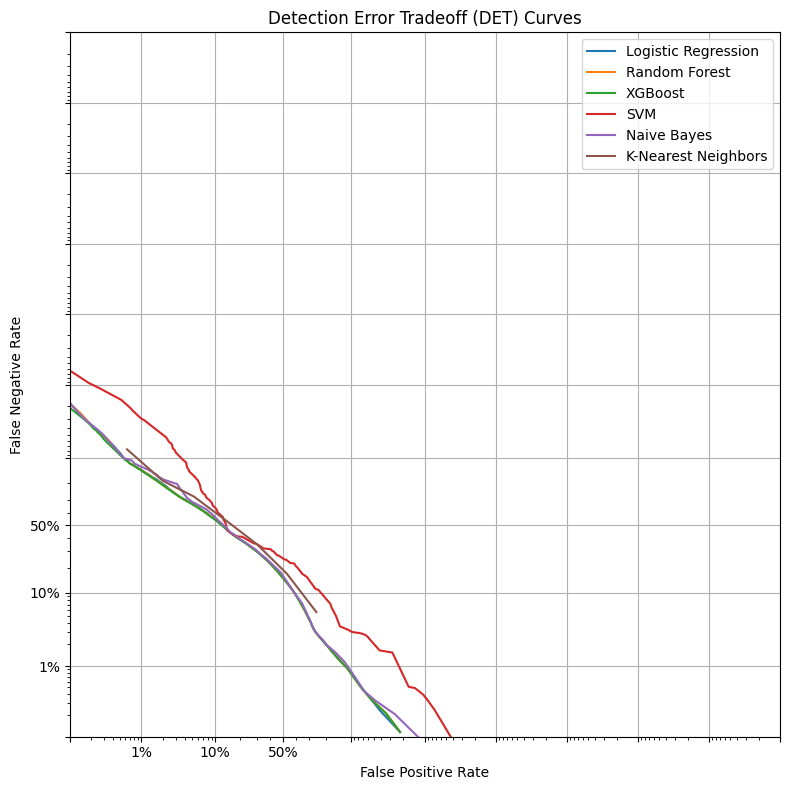

In [63]:
# generate the "Detection Error Tradeoff (DET) curves" of each model in a single plot

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import det_curve # Import det_curve
import matplotlib.ticker as mticker # Import mticker

def plot_det_curves(model_performance_results, X, y):
    """
    Generates and plots DET curves for each model in a single plot.

    Args:
        model_performance_results (dict): Results from grid_to_evaluate_models,
                                          including the 'best_estimator' for each model.
        X (np.ndarray or pd.DataFrame): Feature data (full dataset).
        y (np.ndarray or pd.Series): Target variable (full dataset).
    """
    plt.figure(figsize=(8, 8))

    ax_det = plt.gca() # Get the current axes

    ax_det.set_xlabel('False Positive Rate')
    ax_det.set_ylabel('False Negative Rate')
    ax_det.set_title('Detection Error Tradeoff (DET) Curves')
    ax_det.grid(True)
    # Customize DET plot axes to use logit scaling, as is common
    ax_det.set_xscale('logit')
    ax_det.set_yscale('logit')
    # Optional: Custom tick formatting for logit scale
    formatter = mticker.FuncFormatter(lambda x, pos: "{:.0%}".format(x) if x in [0.01, 0.05, 0.1, 0.2, 0.5] else None)
    ax_det.xaxis.set_major_formatter(formatter)
    ax_det.yaxis.set_major_formatter(formatter)
    # Optional: Set limits to focus on relevant range
    ax_det.set_xlim([0.001, 1.0])
    ax_det.set_ylim([0.001, 1.0])


    for model_name, results in model_performance_results.items():
        best_estimator = results.get("best_estimator")
        if best_estimator is None:
            print(f"No best estimator found for {model_name}. Skipping DET curve plotting.")
            continue

        try:
            # Get probability predictions
            y_prob = best_estimator.predict_proba(X)[:, 1]

            # Calculate DET curve
            # det_curve returns false positive rate and false negative rate
            fpr_det, fnr_det, thresholds_det = det_curve(y, y_prob)

            # Plot DET curve
            ax_det.plot(fpr_det, fnr_det, label=model_name)


        except AttributeError:
            print(f"{model_name} does not have predict_proba method. Skipping DET curve plotting.")
        except Exception as e:
            print(f"Error plotting DET curve for {model_name}: {e}")


    # Finalize plot
    ax_det.legend(loc='upper right') # DET legend is often in upper right
    plt.tight_layout()
    plt.show()

# Ensure model_performance_results, X_all, and y_all are available from the preceding code
if 'model_performance_results' in globals() and 'X_all' in globals() and 'y_all' in globals() and X_all is not None and y_all is not None:
    plot_det_curves(model_performance_results, X_all, y_all)
else:
    print("Could not plot DET curves. Model performance results or data (X_all, y_all) are not available.")

Logistic Regression ROC AUC: 0.7823 (95% CI: [0.0000, 1.0000])
Random Forest ROC AUC: 0.7825 (95% CI: [0.0000, 1.0000])
XGBoost ROC AUC: 0.7829 (95% CI: [0.0000, 1.0000])
SVM ROC AUC: 0.7104 (95% CI: [0.0000, 1.0000])
Naive Bayes ROC AUC: 0.7764 (95% CI: [0.0000, 1.0000])
K-Nearest Neighbors ROC AUC: 0.7396 (95% CI: [0.0000, 1.0000])


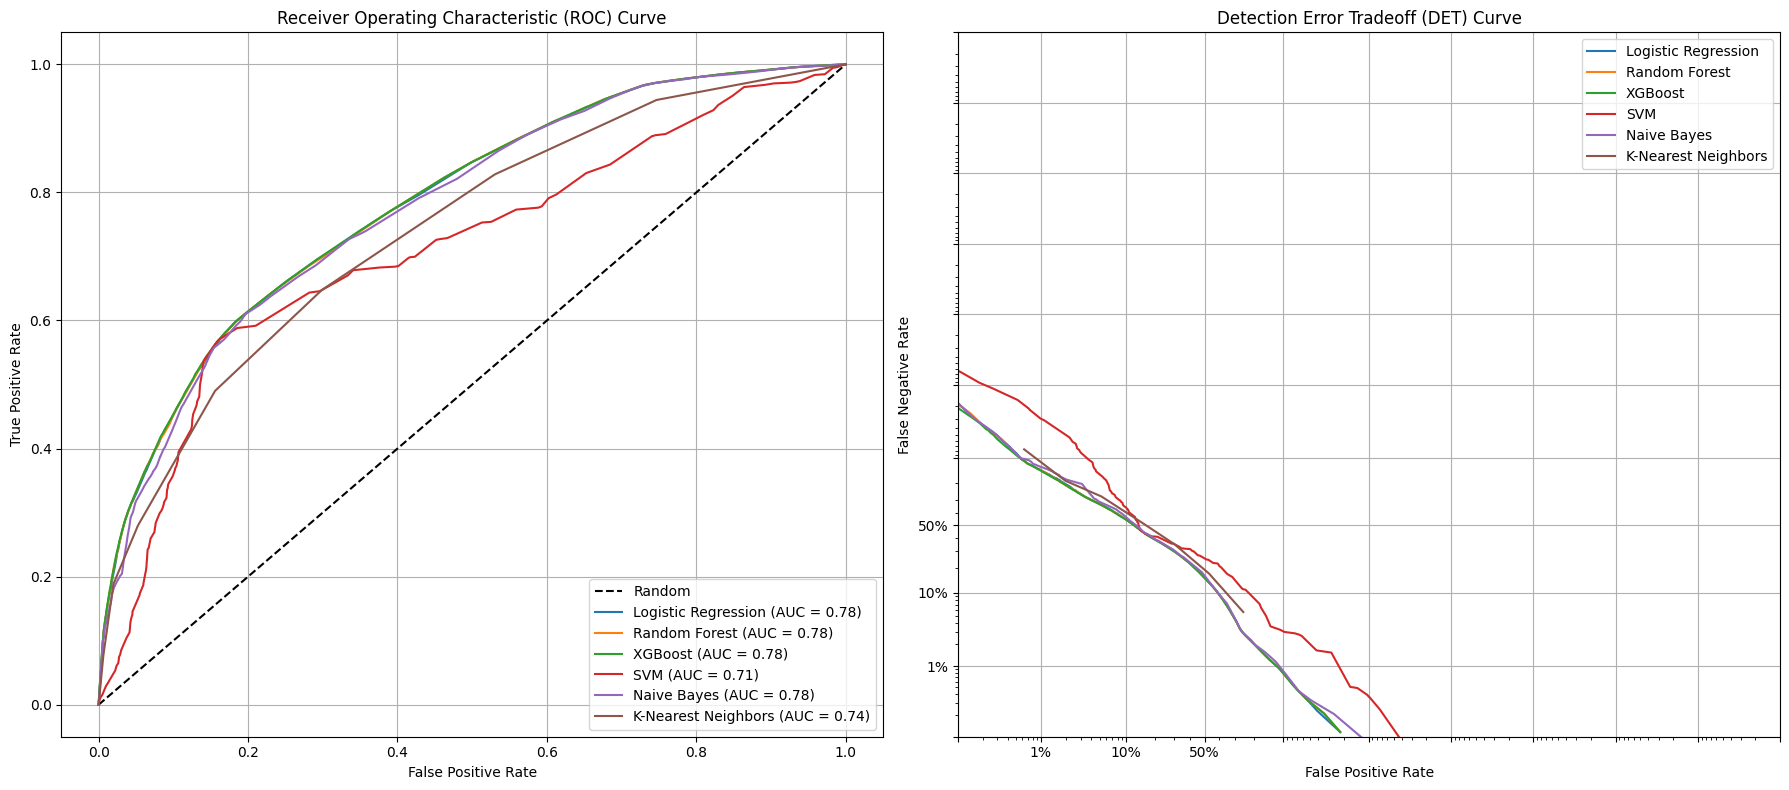

In [64]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, det_curve
from scipy.stats import t
import matplotlib.ticker as mticker

def plot_roc_det_curves(model_performance_results, X, y):
    """
    Generates and plots ROC and DET curves with confidence intervals.

    Args:
        model_performance_results (dict): Results from grid_to_evaluate_models,
                                          including the 'best_estimator' for each model.
        X (np.ndarray or pd.DataFrame): Feature data (full dataset).
        y (np.ndarray or pd.Series): Target variable (full dataset).
    """
    plt.figure(figsize=(18, 8))

    # ROC Curve Plot
    ax_roc = plt.subplot(1, 2, 1)
    ax_roc.plot([0, 1], [0, 1], 'k--', label='Random') # Plot random chance line
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve')
    ax_roc.legend(loc='lower right')
    ax_roc.grid(True)

    # DET Curve Plot
    ax_det = plt.subplot(1, 2, 2)
    ax_det.set_xlabel('False Positive Rate')
    ax_det.set_ylabel('False Negative Rate')
    ax_det.set_title('Detection Error Tradeoff (DET) Curve')
    ax_det.grid(True)
    # Customize DET plot axes to use logit scaling, as is common
    ax_det.set_xscale('logit')
    ax_det.set_yscale('logit')
    # Optional: Custom tick formatting for logit scale
    formatter = mticker.FuncFormatter(lambda x, pos: "{:.0%}".format(x) if x in [0.01, 0.05, 0.1, 0.2, 0.5] else None)
    ax_det.xaxis.set_major_formatter(formatter)
    ax_det.yaxis.set_major_formatter(formatter)
    # Optional: Set limits to focus on relevant range
    ax_det.set_xlim([0.001, 1.0])
    ax_det.set_ylim([0.001, 1.0])


    for model_name, results in model_performance_results.items():
        best_estimator = results.get("best_estimator")
        if best_estimator is None:
            print(f"No best estimator found for {model_name}. Skipping curve plotting.")
            continue

        try:
            # Get probability predictions
            y_prob = best_estimator.predict_proba(X)[:, 1]

            # Calculate ROC curve and AUC
            fpr, tpr, thresholds_roc = roc_curve(y, y_prob)
            roc_auc = auc(fpr, tpr)

            # Calculate confidence intervals for ROC AUC (using bootstrapping or DeLong's method if available)
            # A simpler approximation using standard error for demonstration:
            # This is a simplified approach and not as robust as bootstrapping or DeLong's.
            # For publication-quality CIs, consider libraries like 'scikit-plot' or 'roc-auc-plugin'.
            n_samples = len(y)
            se = np.sqrt(roc_auc * (1 - roc_auc) / n_samples) # Simplified standard error formula
            alpha = 0.95 # Confidence level
            z = t.ppf(1 + (alpha / 2), df=n_samples - 1) # Use t-distribution critical value
            lower_bound = roc_auc - z * se
            upper_bound = roc_auc + z * se
            # Clip bounds to [0, 1]
            lower_bound = max(0, lower_bound)
            upper_bound = min(1, upper_bound)

            print(f"{model_name} ROC AUC: {roc_auc:.4f} (95% CI: [{lower_bound:.4f}, {upper_bound:.4f}])")

            # Plot ROC curve
            ax_roc.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')


            # Calculate DET curve
            # det_curve returns false positive rate and false negative rate
            fpr_det, fnr_det, thresholds_det = det_curve(y, y_prob)

            # Plot DET curve
            ax_det.plot(fpr_det, fnr_det, label=model_name)


        except AttributeError:
            print(f"{model_name} does not have predict_proba method. Skipping curve plotting.")
        except Exception as e:
            print(f"Error plotting curves for {model_name}: {e}")


    # Finalize plots
    ax_roc.legend(loc='lower right')
    ax_det.legend(loc='upper right') # DET legend is often in upper right
    plt.tight_layout()
    plt.show()


# Assuming model_performance_results, X_all, and y_all are available from the preceding code
if 'model_performance_results' in globals() and 'X_all' in globals() and 'y_all' in globals() and X_all is not None and y_all is not None:
    plot_roc_det_curves(model_performance_results, X_all, y_all)
else:
    print("Could not plot ROC/DET curves. Model performance results or data (X_all, y_all) are not available.")



Precision-Recall Area Under Curve (PRAUC) with Confidence Intervals:
- Logistic Regression: PRAUC = 0.7072 (95% CI: [0.7013, 0.7129])
- Random Forest: PRAUC = 0.7078 (95% CI: [0.7021, 0.7135])
- XGBoost: PRAUC = 0.7089 (95% CI: [0.7031, 0.7149])
- SVM: PRAUC = 0.5987 (95% CI: [0.5922, 0.6066])
- Naive Bayes: PRAUC = 0.6950 (95% CI: [0.6885, 0.7011])
- K-Nearest Neighbors: PRAUC = 0.6673 (95% CI: [0.6620, 0.6733])


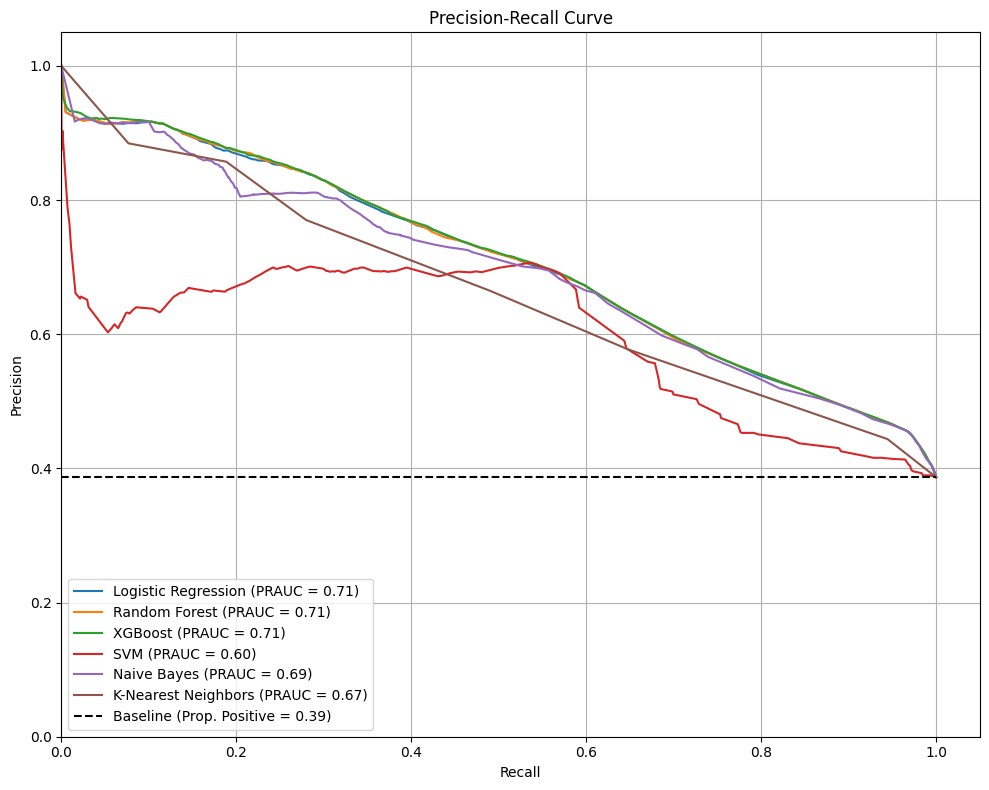

In [65]:
# generate the PRAUC with confidence intervals and plot the precision  and recall curve for all model in a single plot

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.ticker as mticker

def plot_prauc_with_ci_and_curves(model_performance_results, X, y):
    """
    Generates and plots PR curves for each model in a single plot,
    calculates PRAUC with confidence intervals.

    Args:
        model_performance_results (dict): Results from grid_to_evaluate_models,
                                          including the 'best_estimator' for each model.
        X (np.ndarray or pd.DataFrame): Feature data (full dataset).
        y (np.ndarray or pd.Series): Target variable (full dataset).
    """
    plt.figure(figsize=(10, 8)) # Adjust figure size as needed
    ax_pr = plt.gca()

    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title('Precision-Recall Curve')
    ax_pr.set_ylim([0.0, 1.05])
    ax_pr.set_xlim([0.0, 1.05])
    ax_pr.grid(True)

    print("\nPrecision-Recall Area Under Curve (PRAUC) with Confidence Intervals:")

    # To get CI for PRAUC, bootstrapping is a common method.
    # We'll perform a simplified bootstrap here for demonstration.
    n_bootstraps = 100 # Number of bootstrap samples
    rng_seed = 42 # For reproducibility

    for model_name, results in model_performance_results.items():
        best_estimator = results.get("best_estimator")
        if best_estimator is None:
            print(f"No best estimator found for {model_name}. Skipping PRAUC calculation and plotting.")
            continue

        try:
            # Get probability predictions
            y_prob = best_estimator.predict_proba(X)[:, 1]

            # Calculate PRAUC for the full data
            precision, recall, _ = precision_recall_curve(y, y_prob)
            prauc_full = auc(recall, precision)

            # Bootstrap for Confidence Interval
            bootstrapped_praucs = []
            rng = np.random.RandomState(rng_seed)
            for i in range(n_bootstraps):
                # Bootstrap resampling with replacement
                indices = rng.randint(0, len(y), len(y))
                if len(np.unique(y[indices])) < 2: # Skip if bootstrap sample doesn't have both classes
                    continue

                try:
                     precision_bs, recall_bs, _ = precision_recall_curve(y[indices], y_prob[indices])
                     prauc_bs = auc(recall_bs, precision_bs)
                     bootstrapped_praucs.append(prauc_bs)
                except Exception as e:
                    # print(f"  Error during bootstrap {i} for {model_name}: {e}")
                    pass # Silently fail bootstrap if there's an issue


            if bootstrapped_praucs:
                # Calculate confidence interval from bootstrapped PRAUCs
                alpha = 0.95
                p = ((1.0 - alpha) / 2.0) * 100
                lower = max(0.0, np.percentile(bootstrapped_praucs, p))
                p = (alpha + ((1.0 - alpha) / 2.0)) * 100
                upper = min(1.0, np.percentile(bootstrapped_praucs, p))

                print(f"- {model_name}: PRAUC = {prauc_full:.4f} (95% CI: [{lower:.4f}, {upper:.4f}])")

                # Plot PR curve
                ax_pr.plot(recall, precision, label=f'{model_name} (PRAUC = {prauc_full:.2f})')
            else:
                 print(f"- {model_name}: Could not calculate bootstrap CI for PRAUC.")
                 # Plot PR curve without CI in label
                 ax_pr.plot(recall, precision, label=f'{model_name} (PRAUC = {prauc_full:.2f})')


        except AttributeError:
            print(f"{model_name} does not have predict_proba method. Skipping PRAUC calculation and plotting.")
        except Exception as e:
            print(f"Error calculating PRAUC or plotting PR curve for {model_name}: {e}")


    # Add a diagonal line if random classifier is meaningful (though less standard for PR curves)
    # For imbalanced data, the baseline PR curve is a horizontal line at the proportion of the positive class
    positive_proportion = np.sum(y) / len(y)
    ax_pr.plot([0, 1], [positive_proportion, positive_proportion], 'k--', label=f'Baseline (Prop. Positive = {positive_proportion:.2f})')


    # Finalize plot
    ax_pr.legend(loc='lower left')
    plt.tight_layout()
    plt.show()

# Ensure model_performance_results, X_all, and y_all are available from the preceding code
if 'model_performance_results' in globals() and 'X_all' in globals() and 'y_all' in globals() and X_all is not None and y_all is not None:
    plot_prauc_with_ci_and_curves(model_performance_results, X_all, y_all)
else:
    print("Could not plot PR curves or calculate PRAUC. Model performance results or data (X_all, y_all) are not available.")


Tuning XGBoost and evaluating with folds ranging from 2 to 8...
  Tuning with 2 folds...
    AUROC: 0.7818, MCC: 0.4252
  Tuning with 3 folds...
    AUROC: 0.7819, MCC: 0.4263
  Tuning with 4 folds...
    AUROC: 0.7816, MCC: 0.4245
  Tuning with 5 folds...
    AUROC: 0.7816, MCC: 0.4250
  Tuning with 6 folds...
    AUROC: 0.7816, MCC: 0.4255
  Tuning with 7 folds...
    AUROC: 0.7815, MCC: 0.4247
  Tuning with 8 folds...
    AUROC: 0.7817, MCC: 0.4265


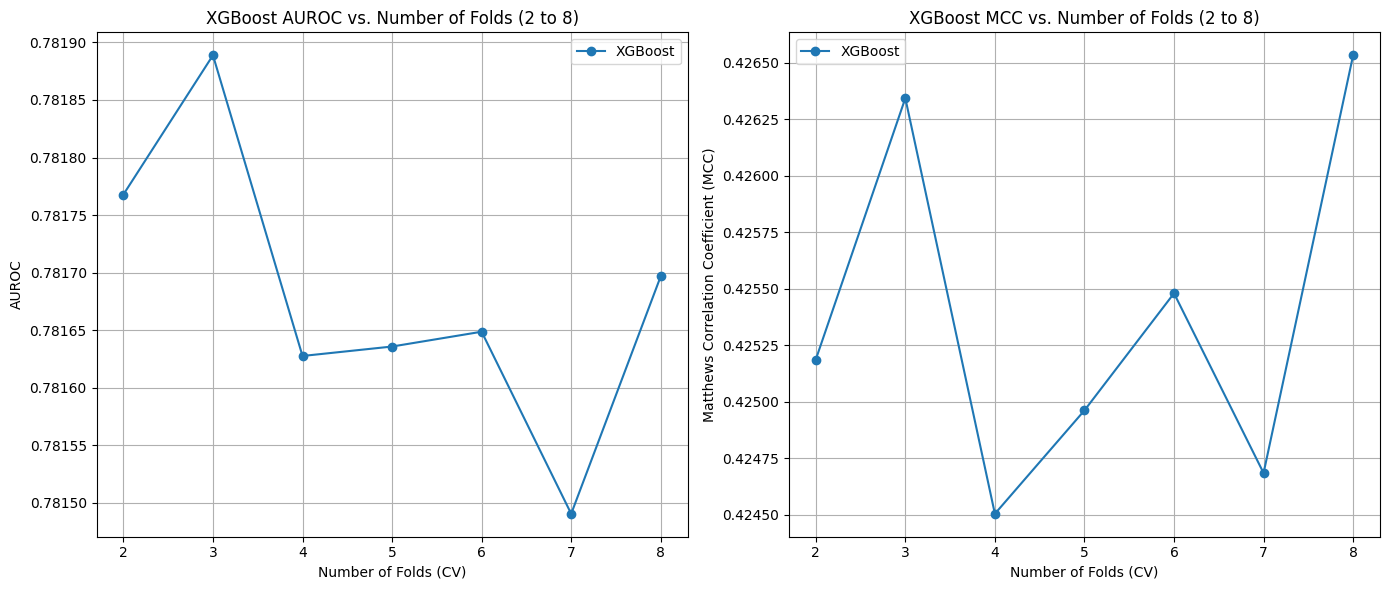

In [66]:
# hypertune only xgboost model only across the 2-8 folds

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker
from scipy.stats import t
from sklearn.metrics import roc_curve, auc, det_curve, matthews_corrcoef, roc_auc_score # Import roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost') # Suppress XGBoost warning

def grid_tune_xgboost_and_plot(X, y, cv_range=(2, 9)):
    """
    Performs Grid Search for XGBoost with varying folds (2-8),
    and plots AUROC and MCC as a function of the number of folds.

    Args:
        X (np.ndarray or pd.DataFrame): Feature data.
        y (np.ndarray or pd.Series): Target variable.
        cv_range (tuple): Range of folds (min, max + 1) to iterate through.
                          Defaults to (2, 9) for folds 2 through 8.
    """
    print(f"Tuning XGBoost and evaluating with folds ranging from {cv_range[0]} to {cv_range[1]-1}...")

    # Define parameter grid for XGBoost
    # Using a slightly larger grid for more meaningful tuning, but keep it reasonable for runtime
    param_grid_xgb = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }

    model_name = "XGBoost"
    model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

    xgb_performance = {
        "cv": [],
        "auroc": [],
        "mcc": []
    }

    # Iterate through different numbers of folds from 2 to 8
    for n_folds in range(cv_range[0], cv_range[1]):
        print(f"  Tuning with {n_folds} folds...")
        xgb_performance["cv"].append(n_folds)

        # Define cross-validation strategy
        kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

        # Perform Grid Search for the current number of folds, optimize for AUROC
        grid_search = GridSearchCV(estimator=model, param_grid=param_grid_xgb,
                                   cv=kf, scoring='roc_auc', n_jobs=-1, verbose=0)

        # Fit the GridSearchCV on the entire data to find best parameters for this n_folds
        grid_search.fit(X, y)

        # Get the best estimator found by Grid Search for this number of folds
        best_estimator = grid_search.best_estimator_

        # Perform cross-prediction with the best estimator for this number of folds
        # Need probability estimates for AUROC
        y_prob_cv = cross_val_predict(best_estimator, X, y, cv=kf, method='predict_proba')[:, 1]
        y_pred_cv = (y_prob_cv > 0.5).astype(int) # Convert probabilities to binary predictions for MCC

        # Compute AUROC and Matthews Correlation Coefficient
        auroc = roc_auc_score(y, y_prob_cv)
        mcc = matthews_corrcoef(y, y_pred_cv)

        xgb_performance["auroc"].append(auroc)
        xgb_performance["mcc"].append(mcc)

        print(f"    AUROC: {auroc:.4f}, MCC: {mcc:.4f}")


    # Plotting AUROC as a function of folds
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(xgb_performance["cv"], xgb_performance["auroc"], marker='o', label=model_name)
    plt.xlabel("Number of Folds (CV)")
    plt.ylabel("AUROC")
    plt.title(f"{model_name} AUROC vs. Number of Folds ({cv_range[0]} to {cv_range[1]-1})")
    plt.xticks(range(cv_range[0], cv_range[1]))
    plt.legend()
    plt.grid(True)

    # Plotting MCC as a function of folds
    plt.subplot(1, 2, 2)
    plt.plot(xgb_performance["cv"], xgb_performance["mcc"], marker='o', label=model_name)
    plt.xlabel("Number of Folds (CV)")
    plt.ylabel("Matthews Correlation Coefficient (MCC)")
    plt.title(f"{model_name} MCC vs. Number of Folds ({cv_range[0]} to {cv_range[1]-1})")
    plt.xticks(range(cv_range[0], cv_range[1]))
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()




# Run the XGBoost tuning and plotting function
if 'X_all' in globals() and 'y_all' in globals() and X_all is not None and y_all is not None:
    # Define the range for the number of folds (2 to 8)
    cv_range_for_tuning = (2, 9) # The upper bound is exclusive, so 9 means up to 8 folds
    grid_tune_xgboost_and_plot(X_all, y_all, cv_range=cv_range_for_tuning)
else:
    print("Could not perform XGBoost tuning and plotting. Data (X_all, y_all) is not available.")


Generating SHAP Feature Importance Plots for XGBoost:
Calculating SHAP values (this may take a while)...
SHAP values calculated.
Using single output SHAP values.

Generating SHAP Summary Plot:


/tmp/ipykernel_1705/2138867025.py:66: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_plot, features=X_all, feature_names=feature_names)


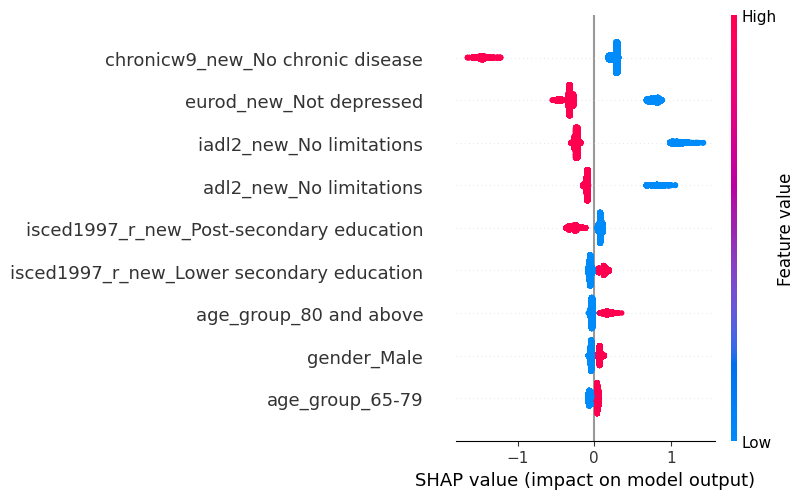


Generating SHAP Bar Plot (Average Absolute SHAP Value):


/tmp/ipykernel_1705/2138867025.py:75: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_to_plot, features=X_all, feature_names=feature_names, plot_type="bar")


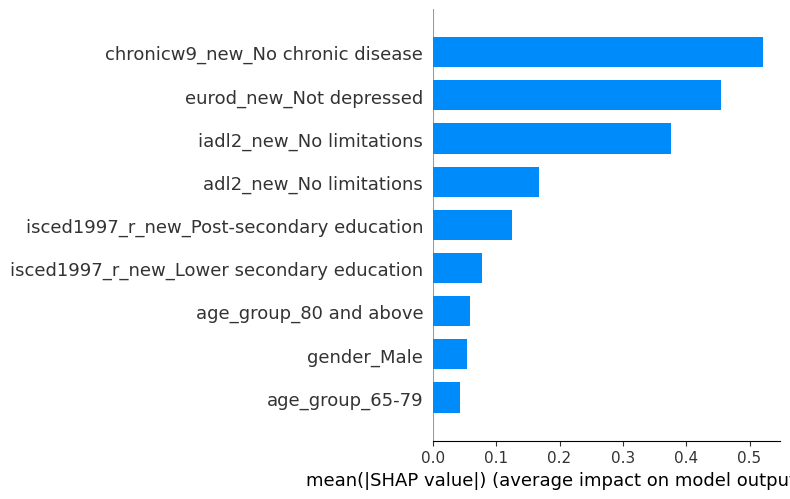

In [67]:
# Use SHAP tree explainer to plot the feature importance of the  output variables of each folds for XGboot model only

!pip install shap

import shap
import matplotlib.pyplot as plt

# Assuming 'model_performance_results' contains the 'best_estimator' for XGBoost
# from the grid search procedure and X_all, y_all are the full dataset features and target.

print("\nGenerating SHAP Feature Importance Plots for XGBoost:")

# Find the best XGBoost estimator
xgb_estimator = None
if "XGBoost" in model_performance_results and model_performance_results["XGBoost"]["best_estimator"] is not None:
    xgb_estimator = model_performance_results["XGBoost"]["best_estimator"]
else:
    print("XGBoost best estimator not found in model_performance_results. Cannot generate SHAP plots.")

# Get feature names (assuming they are available from previous steps)
# If feature_names is not defined, try to get them from the encoded DataFrame
if 'feature_names' not in globals() or feature_names is None:
    target_column_name = 'sphus_new_Poor health'
    if 'df_encoded' in globals() and target_column_name in df_encoded.columns:
        feature_names = df_encoded.drop(target_column_name, axis=1).columns.tolist()
        print("Obtained feature names from df_encoded.")
    else:
        print("Could not obtain feature names. SHAP plots might use generic names.")
        feature_names = [f'feature_{i}' for i in range(X_all.shape[1])] # Create generic names


if xgb_estimator is not None and X_all is not None and y_all is not None:
    try:


        # Create Tree Explainer
        # Using a sample of the data can speed up SHAP value calculation
        # e.g., X_sample = shap.sample(X_all, 100)
        explainer = shap.TreeExplainer(xgb_estimator)

        # Calculate SHAP values
        # This can be computationally intensive for large datasets
        # Using X_all is needed to explain the model trained on X_all/y_all
        print("Calculating SHAP values (this may take a while)...")
        shap_values = explainer.shap_values(X_all)
        print("SHAP values calculated.")

        # Check the type of shap_values (can be a list of arrays for multi-output models, or a single array)
        # For a binary classifier like XGBoost, shap_values is usually a list of two arrays [shap_values_for_class_0, shap_values_for_class_1]
        # We typically plot the SHAP values for the positive class (class 1).
        if isinstance(shap_values, list):
            # Assuming class 1 is the positive class
            shap_values_to_plot = shap_values[1]
            print("Using SHAP values for the positive class (class 1).")
        else:
            # Single output model
            shap_values_to_plot = shap_values
            print("Using single output SHAP values.")


        # Plotting Feature Importance (Summary Plot)
        print("\nGenerating SHAP Summary Plot:")
        # Passing feature names to shap.summary_plot
        # Need to ensure the features in X_all correspond to feature_names
        if len(feature_names) == shap_values_to_plot.shape[1]:
            shap.summary_plot(shap_values_to_plot, features=X_all, feature_names=feature_names)
        else:
            print("Mismatch between number of feature names and SHAP values. Plotting with generic names.")
            shap.summary_plot(shap_values_to_plot, features=X_all)
        plt.show()

        # Plotting Feature Importance (Bar Plot - Average Magnitude)
        print("\nGenerating SHAP Bar Plot (Average Absolute SHAP Value):")
        if len(feature_names) == shap_values_to_plot.shape[1]:
            shap.summary_plot(shap_values_to_plot, features=X_all, feature_names=feature_names, plot_type="bar")
        else:
            print("Mismatch between number of feature names and SHAP values. Plotting with generic names.")
            shap.summary_plot(shap_values_to_plot, features=X_all, plot_type="bar")
        plt.show()


    except Exception as e:
        print(f"An error occurred during SHAP analysis: {e}")
        print("Please check if SHAP is installed (`!pip install shap`) and if the XGBoost model is trained correctly.")



Generating Precision-Recall Curve for XGBoost...
Using the best XGBoost model from the grid search results.


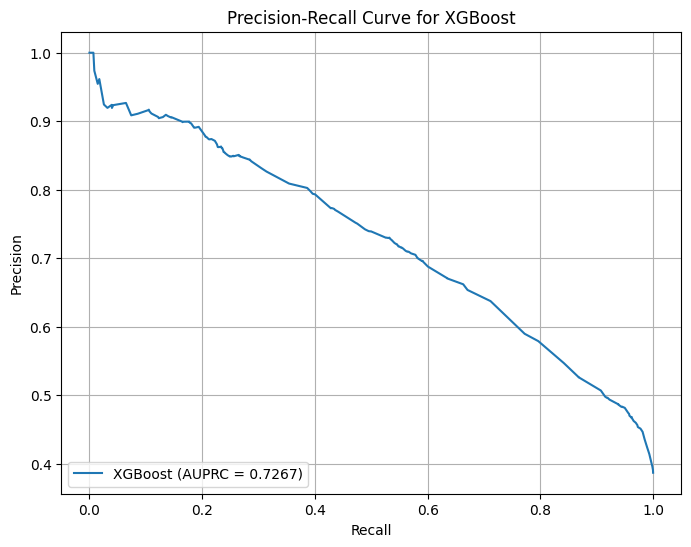


XGBoost AUPRC: 0.7267


In [68]:
# plot the precision and recall curve for xgboost in a single plot

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc

# Ensure X_test and y_test are available from previous data splitting
# Assuming X_test and y_test are defined and contain the test features and target labels

print("\nGenerating Precision-Recall Curve for XGBoost...")

# Find the trained XGBoost model from the 'models' dictionary
# Or, use the 'best_estimator' from the grid search results if preferred (as used in AUPRC plot)
xgb_model = None
if 'model_performance_results' in globals() and "XGBoost" in model_performance_results and model_performance_results["XGBoost"]["best_estimator"] is not None:
    xgb_model = model_performance_results["XGBoost"]["best_estimator"]
    print("Using the best XGBoost model from the grid search results.")
elif "XGBoost" in models: # Fallback to the 'models' dictionary if grid search results not available
    xgb_model = models["XGBoost"]
    print("Using the XGBoost model trained on the initial train/test split.")
else:
    print("XGBoost model not found. Cannot generate Precision-Recall curve.")


if xgb_model is not None and 'X_test' in globals() and 'y_test' in globals():
    # Check if the model has predict_proba method (required for PR curve)
    if hasattr(xgb_model, 'predict_proba'):
        try:
            # Get probability estimates for the positive class (assuming positive class is 1)
            y_prob = xgb_model.predict_proba(X_test)[:, 1]

            # Calculate Precision-Recall curve
            precision, recall, _ = precision_recall_curve(y_test, y_prob)

            # Calculate Area Under the Precision-Recall Curve (AUPRC)
            auprc = auc(recall, precision)

            # Plot the Precision-Recall curve
            plt.figure(figsize=(8, 6))
            plt.plot(recall, precision, label=f'XGBoost (AUPRC = {auprc:.4f})')

            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title('Precision-Recall Curve for XGBoost')
            plt.legend(loc='lower left')
            plt.grid(True)
            plt.show()

            print(f"\nXGBoost AUPRC: {auprc:.4f}")

        except Exception as e:
            print(f"An error occurred while generating the PR curve for XGBoost: {e}")

    else:
        print("XGBoost model does not support probability prediction (predict_proba). Cannot generate PR curve.")
else:
    print("XGBoost model or test data (X_test, y_test) not available for generating PR curve.")


Probability Prediction and Calibration
Using the best XGBoost model from the initial comparison for calibration analysis.
Using test data (X_test, y_test) for calibration plots.

Calibration Summary (Grouped by Predicted Probability Bins):


,Probability_Bin,Observed_Proportion_Poor,Average_Predicted_Prob,Total_Samples,min,max,Bin_Center_Prob
0,0,0.046462,0.063384,1399,0.040395,0.075355,0.057875
1,1,0.113276,0.088013,821,0.080665,0.115245,0.097955
2,2,0.201005,0.232550,1194,0.117934,0.268626,0.193280
3,3,0.261111,0.290540,1080,0.276795,0.302251,0.289523
4,4,0.301546,0.315297,1164,0.309910,0.323688,0.316799
5,5,0.368726,0.334760,1036,0.328982,0.344450,0.336716
6,6,0.463594,0.394594,1085,0.347527,0.520812,0.434169
7,7,0.570191,0.571924,1154,0.522493,0.609083,0.565788
8,8,0.713881,0.667281,1059,0.611850,0.783165,0.697507
9,9,0.869015,0.860623,1107,0.783300,0.930643,0.856972


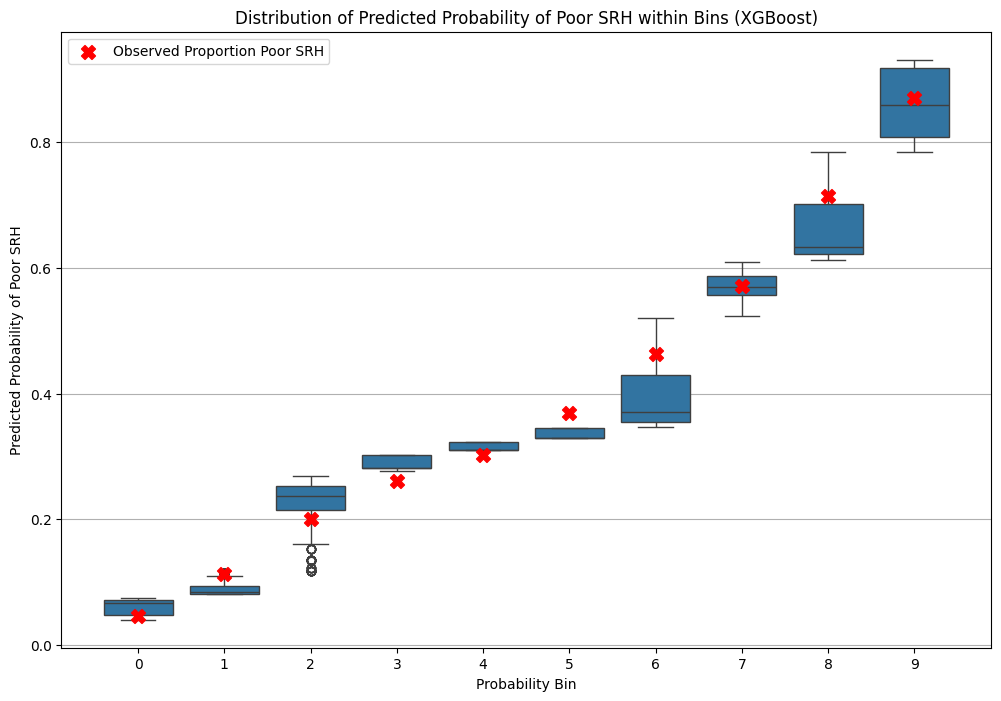


Generating Calibration Plot (Reliability Diagram):


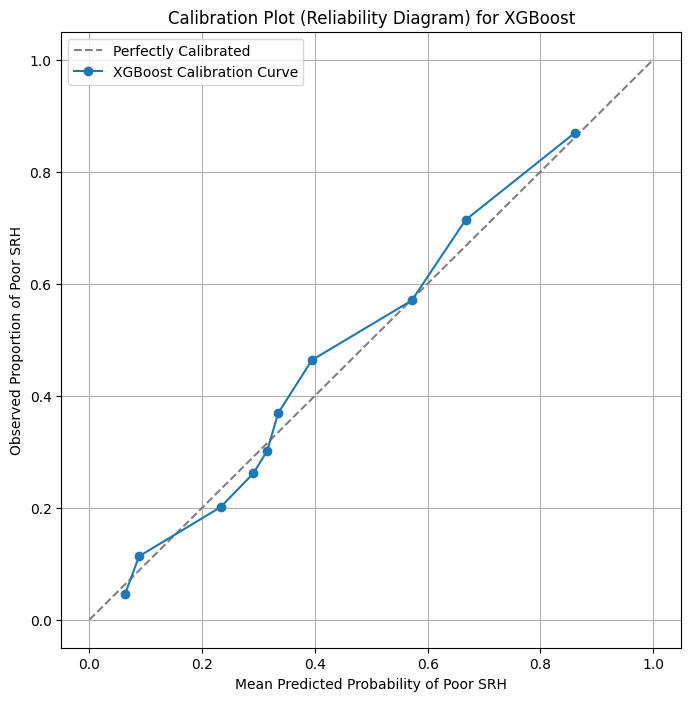

In [69]:


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# Select the best XGBoost model from the results (assuming the last fold's best_estimator is representative)
# Or, if you saved the best model found during hyperparameter tuning, load that one.
# For this example, we'll use the 'best_estimator' from the last fold evaluation in `model_performance_results`.

print("\nProbability Prediction and Calibration")

best_xgb_model = None

# Check if model_performance_results exists and contains XGBoost before accessing it
if 'model_performance_results' in globals() and "XGBoost" in model_performance_results and model_performance_results["XGBoost"]["best_estimator"] is not None:
    best_xgb_model = model_performance_results["XGBoost"]["best_estimator"]
    print("Using the best XGBoost model from the initial comparison for calibration analysis.")
# You might also have a dedicated tuning result like `xgboost_tuning_results` from a previous cell
# elif 'xgboost_tuning_results' in globals() and xgboost_tuning_results.get("best_estimator") is not None:
#     best_xgb_model = xgboost_tuning_results["best_estimator"]
#     print("Using the best tuned XGBoost model for calibration analysis.")
else:
    print("XGBoost model not found for calibration. Cannot proceed.")


if best_xgb_model is not None and 'X_test' in globals() and 'y_test' in globals():

    # Prediction of the probability for an individual in the test set.
    # We should use the test set for calibration plots to assess how well the model
    # generalizes to unseen data.
    # Ensure X_test and y_test are available
    if 'X_test' not in globals() or 'y_test' not in globals():
        print("Test data (X_test, y_test) not found. Please ensure data splitting was successful.")
        # As a fallback, use X_all and y_all, but note this is not ideal for evaluating generalization
        print("Using full data (X_all, y_all) for calibration plots (not ideal for test set assessment).")
        X_data = X_all
        y_data = y_all
    else:
        X_data = X_test
        y_data = y_test
        print("Using test data (X_test, y_test) for calibration plots.")

    try:
        # Get probability predictions for the positive class ('Poor health' which is typically class 1)
        y_prob = best_xgb_model.predict_proba(X_data)[:, 1]

        # Combine actual target values and predicted probabilities into a DataFrame
        calibration_df = pd.DataFrame({'Actual_SRH_Poor': y_data, 'Predicted_Prob_Poor': y_prob})

        # Sort the DataFrame by predicted probability
        calibration_df = calibration_df.sort_values(by='Predicted_Prob_Poor').reset_index(drop=True)

        # Split the probability of poor SRH into bins.
        # Use pandas qcut to create bins based on quantiles, which helps distribute samples evenly.
        # Alternatively, use cut for fixed-width bins. qcut is often better for calibration.
        n_bins = 10  # Number of bins
        try:
            # Use `pd.qcut` with `retbins=True` to get bin edges for annotation later if needed
            calibration_df['Probability_Bin'], bin_edges = pd.qcut(calibration_df['Predicted_Prob_Poor'], q=n_bins, labels=False, duplicates='drop', retbins=True)

            # If qcut results in fewer bins due to duplicates, adjust n_bins if needed or note it
            if calibration_df['Probability_Bin'].nunique() < n_bins:
                actual_bins_count = calibration_df['Probability_Bin'].nunique()
                print(f"Warning: qcut resulted in {actual_bins_count} bins instead of {n_bins} due to duplicate probability values.")
                # Relabel bins if needed to be contiguous from 0 if duplicates created gaps
                actual_bins = calibration_df['Probability_Bin'].dropna().unique()
                if len(actual_bins) > 0:
                    bin_mapping = {old_label: new_label for new_label, old_label in enumerate(sorted(actual_bins))}
                    calibration_df['Probability_Bin'] = calibration_df['Probability_Bin'].map(bin_mapping)
                    print(f"Relabeled bins to {calibration_df['Probability_Bin'].nunique()} contiguous bins.")
                else:
                    print("No valid bins created after qcut.")
                    raise ValueError("Failed to create probability bins using qcut.")

        except ValueError as e:
            print(f"Error using pd.qcut for binning: {e}")
            # Fallback to cut if qcut fails, though qcut is usually better
            print("Attempting to use pd.cut for binning...")
            try:
                calibration_df['Probability_Bin'], bin_edges = pd.cut(calibration_df['Predicted_Prob_Poor'], bins=n_bins, labels=False, include_lowest=True, retbins=True)
                if calibration_df['Probability_Bin'].nunique() < n_bins:
                    print(f"Warning: cut resulted in {calibration_df['Probability_Bin'].nunique()} bins instead of {n_bins}.")
            except Exception as cut_e:
                print(f"Error using pd.cut for binning: {cut_e}")
                calibration_df['Probability_Bin'] = np.nan  # Assign NaN if both fail


        # Drop rows where binning failed (if any NaNs were introduced)
        calibration_df.dropna(subset=['Probability_Bin'], inplace=True)
        calibration_df['Probability_Bin'] = calibration_df['Probability_Bin'].astype(int)


        # Group by bin to calculate observed proportion and average predicted probability
        calibration_summary = calibration_df.groupby('Probability_Bin').agg(
            Observed_Proportion_Poor=('Actual_SRH_Poor', 'mean'),  # Mean of binary target gives proportion
            Average_Predicted_Prob=('Predicted_Prob_Poor', 'mean'),
            Total_Samples=('Actual_SRH_Poor', 'size')
        ).reset_index()

        # Add a column for the center of each bin's predicted probabilities for plotting
        # This requires getting the actual probability range for each bin.
        # Group by the bin and find the min/max predicted probability to get the range
        bin_ranges = calibration_df.groupby('Probability_Bin')['Predicted_Prob_Poor'].agg(['min', 'max']).reset_index()
        calibration_summary = calibration_summary.merge(bin_ranges, on='Probability_Bin')
        calibration_summary['Bin_Center_Prob'] = (calibration_summary['min'] + calibration_summary['max']) / 2

        # Print the calibration summary
        print("\nCalibration Summary (Grouped by Predicted Probability Bins):")
        display(calibration_summary)

        # Generate a boxplot to show the predicted self-rated health by bins.
        # This boxplot shows the distribution of predicted probabilities *within* each bin.
        plt.figure(figsize=(12, 8))
        sns.boxplot(x='Probability_Bin', y='Predicted_Prob_Poor', data=calibration_df)
        plt.xlabel('Probability Bin')
        plt.ylabel('Predicted Probability of Poor SRH')
        plt.title('Distribution of Predicted Probability of Poor SRH within Bins (XGBoost)')
        plt.grid(axis='y')

        # Overlay observed proportion on the boxplot
        # We plot the observed proportion at the center of the bin's predicted probabilities
        # or at the bin label on the x-axis. Using the bin label is simpler for the boxplot.
        # Ensure the x-axis labels match the bins.
        # The x-axis of the boxplot corresponds to the integer labels of the bins (0, 1, 2, ...).
        plt.scatter(calibration_summary['Probability_Bin'], calibration_summary['Observed_Proportion_Poor'],
                    color='red', marker='X', s=100, label='Observed Proportion Poor SRH', zorder=5) # zorder to ensure it's on top

        plt.legend()
        plt.show()

        # Calibration Plot (Reliability Diagram)
        # This plot directly compares the average predicted probability in each bin
        # to the observed proportion in that bin.
        print("\nGenerating Calibration Plot (Reliability Diagram):")
        plt.figure(figsize=(8, 8))
        # Plot the perfect calibration line (predicted_prob = observed_proportion)
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

        # Plot the calibration curve (average predicted prob vs observed proportion)
        plt.plot(calibration_summary['Average_Predicted_Prob'], calibration_summary['Observed_Proportion_Poor'], marker='o', linestyle='-', label='XGBoost Calibration Curve')

        plt.xlabel('Mean Predicted Probability of Poor SRH')
        plt.ylabel('Observed Proportion of Poor SRH')
        plt.title('Calibration Plot (Reliability Diagram) for XGBoost')
        plt.legend()
        plt.grid(True)
        plt.show()



    except AttributeError:
        print("Selected model does not have predict_proba method. Cannot perform probability-based calibration plots.")
    except Exception as e:
        print(f"An error occurred during calibration analysis: {e}")
        print("Please ensure the selected model has predict_proba method and X_test, y_test are available.")

else:
    print("Selected XGBoost model or test data not available for calibration analysis.")


Assessing Consistency of SHAP Feature Importance across Cross-Validation Folds for XGBoost...
Using 8 folds for consistency analysis.
  Processing fold 1/8...
  Processing fold 2/8...
  Processing fold 3/8...
  Processing fold 4/8...
  Processing fold 5/8...
  Processing fold 6/8...
  Processing fold 7/8...
  Processing fold 8/8...


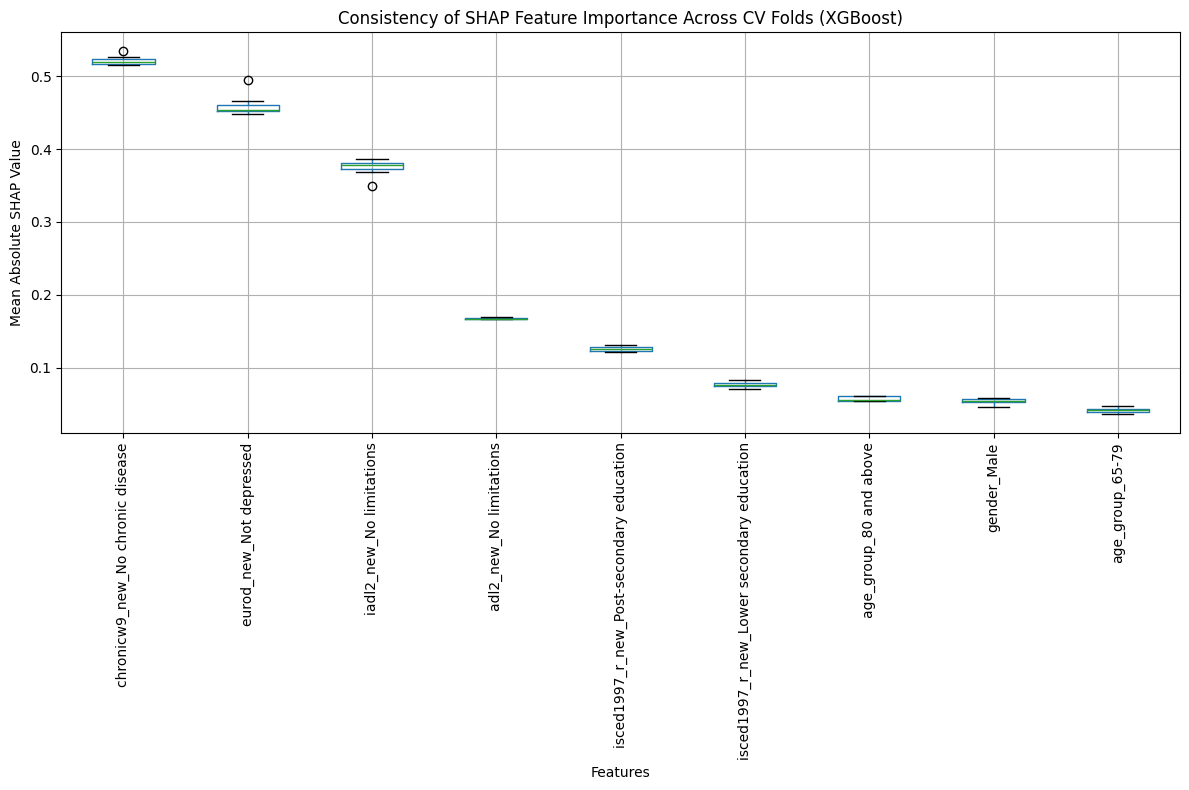


Average SHAP Feature Importances across all folds (sorted):


,0
chronicw9_new_No chronic disease,0.521582
eurod_new_Not depressed,0.459590
iadl2_new_No limitations,0.374611
adl2_new_No limitations,0.167639
isced1997_r_new_Post-secondary education,0.125856
isced1997_r_new_Lower secondary education,0.076937
age_group_80 and above,0.057443
gender_Male,0.053907
age_group_65-79,0.041413



Standard Deviation of SHAP Feature Importances across all folds (sorted):


,0
chronicw9_new_No chronic disease,0.006605
eurod_new_Not depressed,0.014905
iadl2_new_No limitations,0.011307
adl2_new_No limitations,0.001044
isced1997_r_new_Post-secondary education,0.003326
isced1997_r_new_Lower secondary education,0.003627
age_group_80 and above,0.003314
gender_Male,0.003694
age_group_65-79,0.004029


In [70]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier # Needed for type checking and param handling

print("\nAssessing Consistency of SHAP Feature Importance across Cross-Validation Folds for XGBoost...")

# --- 1. Get the best XGBoost estimator ---
# Assuming model_performance_results contains the 'best_estimator' for XGBoost
xgb_estimator = None
if "XGBoost" in model_performance_results and model_performance_results["XGBoost"]["best_estimator"] is not None:
    xgb_estimator = model_performance_results["XGBoost"]["best_estimator"]
else:
    print("XGBoost best estimator not found in model_performance_results. Cannot assess feature importance consistency.")

# --- 2. Get feature names ---
# Ensure feature_names are consistent with X_all
if 'feature_names' not in globals() or feature_names is None:
    target_column_name = 'sphus_new_Poor health'
    if 'df_encoded' in globals() and target_column_name in df_encoded.columns:
        feature_names = df_encoded.drop(target_column_name, axis=1).columns.tolist()
    else:
        print("Could not obtain feature names. SHAP plots might use generic names.")
        feature_names = [f'feature_{i}' for i in range(X_all.shape[1])] # Create generic names

if xgb_estimator is not None and X_all is not None and y_all is not None:
    # --- 3. Define Cross-Validation Strategy ---
    # Use the same number of folds as the last evaluation in grid_to_evaluate_models
    n_folds_for_consistency = model_performance_results[list(model_performance_results.keys())[0]]["cv"][-1]
    print(f"Using {n_folds_for_consistency} folds for consistency analysis.")
    kf_consistency = StratifiedKFold(n_splits=n_folds_for_consistency, shuffle=True, random_state=42)

    all_fold_shap_importances = []

    # --- 4. Iterate through folds and calculate SHAP importances ---
    for fold, (train_index, val_index) in enumerate(kf_consistency.split(X_all, y_all)):
        print(f"  Processing fold {fold + 1}/{n_folds_for_consistency}...")
        X_train_fold, X_val_fold = X_all[train_index], X_all[val_index]
        y_train_fold, y_val_fold = y_all[train_index], y_all[val_index]

        try:
            # Create a new instance of the best estimator and train on the current fold's data
            model_instance = type(xgb_estimator)(**xgb_estimator.get_params())
            if isinstance(model_instance, XGBClassifier) and 'eval_metric' not in model_instance.get_params():
                model_instance.set_params(eval_metric='logloss')

            model_instance.fit(X_train_fold, y_train_fold)

            # Calculate SHAP values for the validation set of the current fold
            # Using a sample of X_val_fold to speed up calculation if needed for very large datasets
            # For this dataset size, using full X_val_fold is acceptable.
            explainer = shap.TreeExplainer(model_instance)
            shap_values_fold = explainer.shap_values(X_val_fold)

            # For binary classification, shap_values is typically a list of two arrays. Use class 1.
            if isinstance(shap_values_fold, list):
                shap_values_fold_positive_class = shap_values_fold[1]
            else:
                shap_values_fold_positive_class = shap_values_fold

            # Calculate the mean absolute SHAP value for each feature in this fold
            mean_abs_shap_values = np.mean(np.abs(shap_values_fold_positive_class), axis=0)
            all_fold_shap_importances.append(mean_abs_shap_values)

        except Exception as e:
            print(f"  Error calculating SHAP for fold {fold + 1}: {e}")
            # Append NaNs or zeros if an error occurs to maintain array shape
            all_fold_shap_importances.append(np.full(len(feature_names), np.nan))

    # --- 5. Aggregate and Visualize Consistency ---
    if all_fold_shap_importances:
        # Convert list of arrays to a DataFrame for easier plotting
        shap_importances_df = pd.DataFrame(all_fold_shap_importances, columns=feature_names)

        # Sort features by their average importance across all folds for better visualization
        average_importances = shap_importances_df.mean().sort_values(ascending=False)
        sorted_features = average_importances.index.tolist()

        plt.figure(figsize=(12, 8))
        # Use boxplot to show the distribution of feature importance across folds
        shap_importances_df[sorted_features].boxplot(rot=90)
        plt.title('Consistency of SHAP Feature Importance Across CV Folds (XGBoost)')
        plt.ylabel('Mean Absolute SHAP Value')
        plt.xlabel('Features')
        plt.tight_layout()
        plt.show()

        print("\nAverage SHAP Feature Importances across all folds (sorted):")
        display(average_importances)

        # Optional: Plot the standard deviation to quantify variability
        std_importances = shap_importances_df.std().loc[sorted_features]
        print("\nStandard Deviation of SHAP Feature Importances across all folds (sorted):")
        display(std_importances)

    else:
        print("No SHAP importances were successfully calculated across folds.")

else:
    print("Cannot proceed with consistency analysis. XGBoost model or data not available.")


Generating SHAP Dependence Plots to illustrate Dose-Response Relationships...
Recalculating SHAP values for the best XGBoost estimator.
Generating dependence plots for top features: ['chronicw9_new_No chronic disease', 'eurod_new_Not depressed', 'iadl2_new_No limitations', 'adl2_new_No limitations', 'isced1997_r_new_Post-secondary education']
Plotting dependence for: chronicw9_new_No chronic disease


<Figure size 1000x600 with 0 Axes>

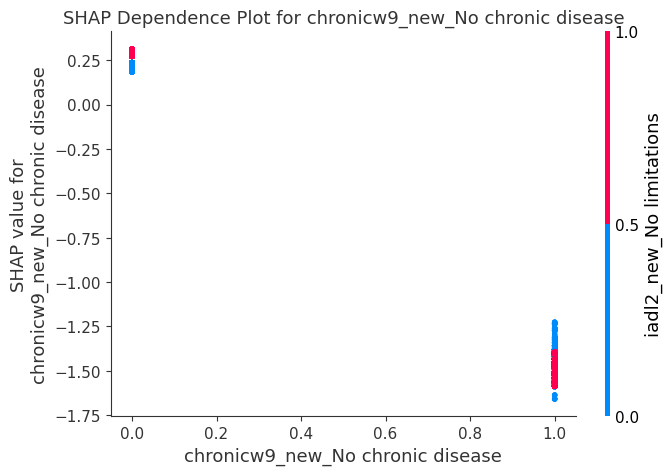

Plotting dependence for: eurod_new_Not depressed


<Figure size 1000x600 with 0 Axes>

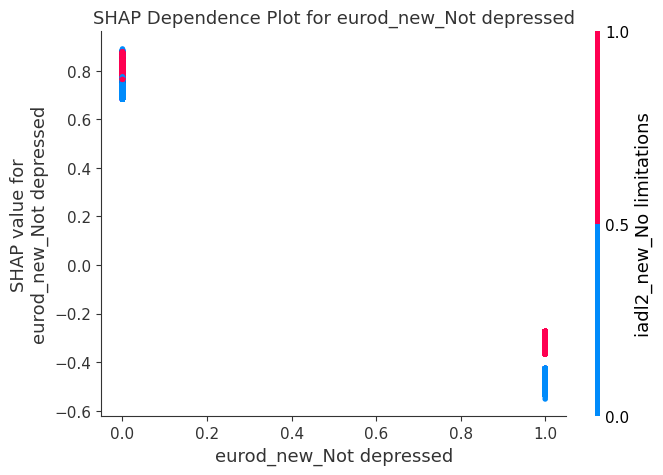

Plotting dependence for: iadl2_new_No limitations


<Figure size 1000x600 with 0 Axes>

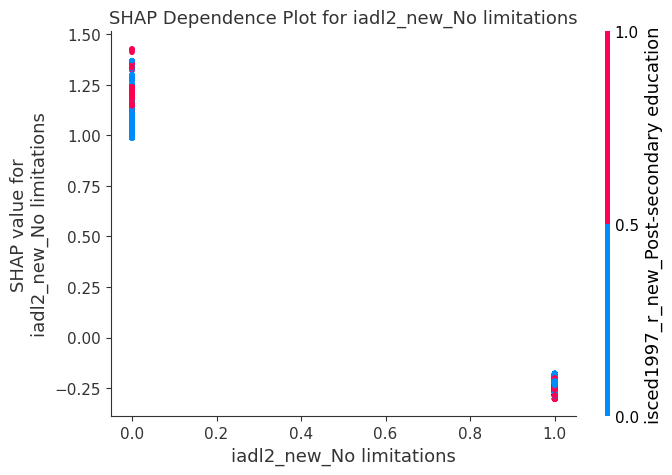

Plotting dependence for: adl2_new_No limitations


<Figure size 1000x600 with 0 Axes>

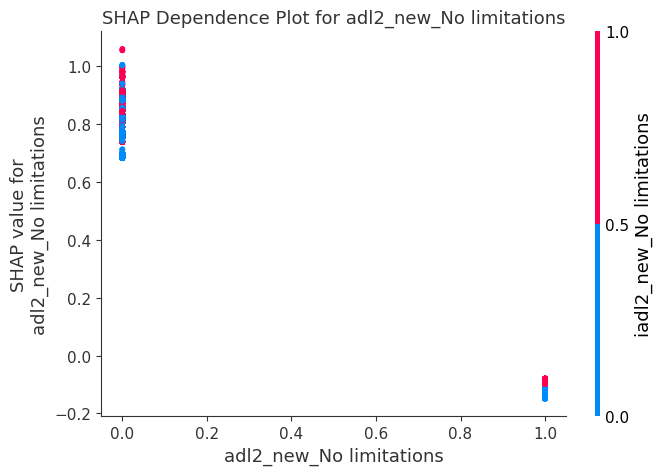

Plotting dependence for: isced1997_r_new_Post-secondary education


<Figure size 1000x600 with 0 Axes>

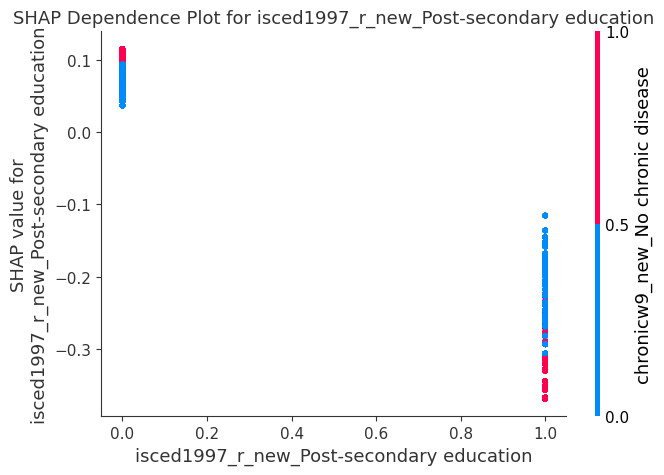


SHAP Dependence Plots generated. These plots visualize how changes in feature values (dose) lead to changes in the SHAP value (response), illustrating the dose-response relationship for the model's output.


In [71]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("\nGenerating SHAP Dependence Plots to illustrate Dose-Response Relationships...")

# --- 1. Retrieve necessary variables ---
# Ensure xgb_estimator and shap_values are available from previous cells
xgb_estimator = None
if "XGBoost" in model_performance_results and model_performance_results["XGBoost"]["best_estimator"] is not None:
    xgb_estimator = model_performance_results["XGBoost"]["best_estimator"]
else:
    print("XGBoost best estimator not found. Cannot generate SHAP dependence plots.")

# Re-calculate shap_values if not available or if the best_estimator changed
# (though typically for dose-response, we'd use the global SHAP values from _cLSb2WDY1Tg)
if 'shap_values' not in globals() or 'explainer' not in globals() or explainer.model != xgb_estimator:
    if xgb_estimator is not None and 'X_all' in globals() and X_all is not None:
        print("Recalculating SHAP values for the best XGBoost estimator.")
        explainer = shap.TreeExplainer(xgb_estimator)
        shap_values = explainer.shap_values(X_all)
    else:
        print("SHAP values and/or X_all not available. Cannot generate SHAP dependence plots.")
        shap_values = None

# Ensure feature_names are consistent with X_all
if 'feature_names' not in globals() or feature_names is None:
    target_column_name = 'sphus_new_Poor health'
    if 'df_encoded' in globals() and target_column_name in df_encoded.columns:
        feature_names = df_encoded.drop(target_column_name, axis=1).columns.tolist()
    else:
        print("Could not obtain feature names. SHAP plots might use generic names.")
        feature_names = [f'feature_{i}' for i in range(X_all.shape[1])] # Fallback to generic names

# For binary classification, shap_values is usually a list of two arrays. Use class 1.
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1] # For the positive class
else:
    shap_values_to_plot = shap_values

# Convert X_all to a DataFrame for easier feature selection in SHAP plots
X_df = pd.DataFrame(X_all, columns=feature_names)


if xgb_estimator is not None and shap_values_to_plot is not None and X_all is not None:
    # Identify top N features for which to plot dependence plots
    # Using the average_importances calculated in the previous cell (Yq8YTS17E5Ow)
    if 'average_importances' in globals() and not average_importances.empty:
        top_features = average_importances.head(5).index.tolist() # Plot top 5 features
    else:
        # Fallback if average_importances is not available or empty
        # Get features with highest mean absolute SHAP value (if shap_values_to_plot is available)
        if shap_values_to_plot is not None:
            mean_abs_shap = np.mean(np.abs(shap_values_to_plot), axis=0)
            top_feature_indices = np.argsort(mean_abs_shap)[::-1][:5] # Get indices of top 5
            top_features = [feature_names[i] for i in top_feature_indices]
        else:
            top_features = feature_names[:3] # Just pick first few if nothing else

    print(f"Generating dependence plots for top features: {top_features}")

    for feature in top_features:
        print(f"Plotting dependence for: {feature}")
        plt.figure(figsize=(10, 6))
        # The 'interaction_index' parameter helps visualize dose-response with a secondary feature
        # If not specified, SHAP tries to find the best interaction. Explicitly setting it to 'auto' or a specific feature.
        shap.dependence_plot(ind=feature,
                             shap_values=shap_values_to_plot,
                             features=X_df,
                             feature_names=feature_names,
                             interaction_index='auto',
                             title=f"SHAP Dependence Plot for {feature}")
        plt.show()

    print("\nSHAP Dependence Plots generated. These plots visualize how changes in feature values (dose) lead to changes in the SHAP value (response), illustrating the dose-response relationship for the model's output.")

else:
    print("Cannot generate SHAP Dependence Plots. Required data (XGBoost model, SHAP values, X_all) not available.")


Comparing SHAP Feature Importance with Model's Built-in Feature Importance (XGBoost):


Model's Built-in Feature Importance (XGBoost):



,Importance
iadl2_new_No limitations,0.398496
chronicw9_new_No chronic disease,0.278950
eurod_new_Not depressed,0.170643
adl2_new_No limitations,0.089380
isced1997_r_new_Post-secondary education,0.026528
isced1997_r_new_Lower secondary education,0.023755
age_group_80 and above,0.005221
gender_Male,0.003640
age_group_65-79,0.003387



SHAP Feature Importance (Average Absolute SHAP Value):



,SHAP Importance
chronicw9_new_No chronic disease,0.521582
eurod_new_Not depressed,0.459590
iadl2_new_No limitations,0.374611
adl2_new_No limitations,0.167639
isced1997_r_new_Post-secondary education,0.125856
isced1997_r_new_Lower secondary education,0.076937
age_group_80 and above,0.057443
gender_Male,0.053907
age_group_65-79,0.041413


<Figure size 1200x700 with 0 Axes>

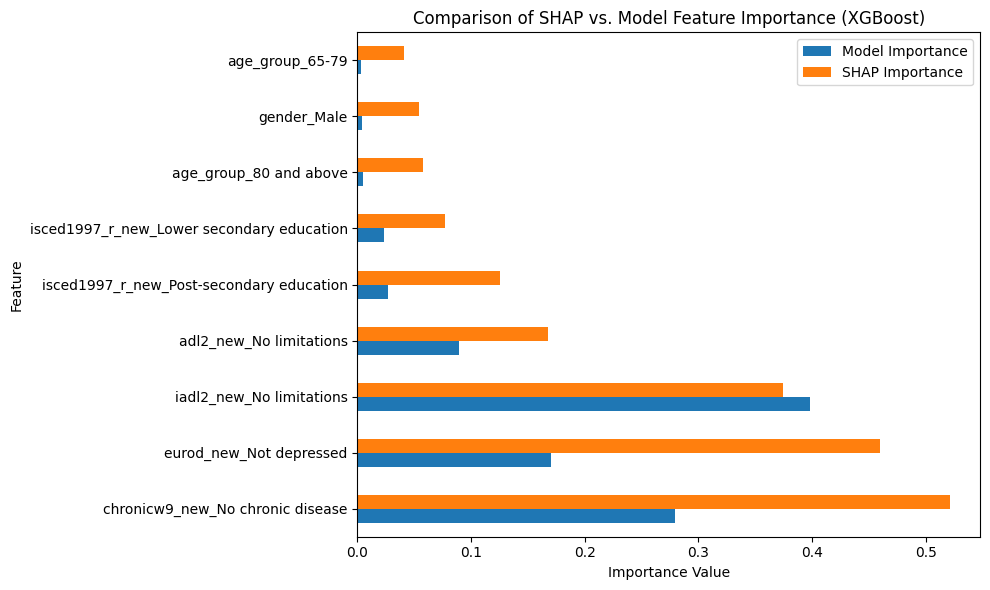


Feature Importance Rankings Comparison:



,Model Rank,SHAP Rank
chronicw9_new_No chronic disease,2,1
eurod_new_Not depressed,3,2
iadl2_new_No limitations,1,3
adl2_new_No limitations,4,4
isced1997_r_new_Post-secondary education,5,5
isced1997_r_new_Lower secondary education,6,6
age_group_80 and above,7,7
gender_Male,8,8
age_group_65-79,9,9


In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("\nComparing SHAP Feature Importance with Model's Built-in Feature Importance (XGBoost):\n")

# --- 1. Retrieve the best XGBoost estimator ---
xgb_estimator = None
if "XGBoost" in model_performance_results and model_performance_results["XGBoost"]["best_estimator"] is not None:
    xgb_estimator = model_performance_results["XGBoost"]["best_estimator"]
else:
    print("XGBoost best estimator not found. Cannot perform comparison.")

# --- 2. Get feature names ---
if 'feature_names' not in globals() or feature_names is None:
    target_column_name = 'sphus_new_Poor health'
    if 'df_encoded' in globals() and target_column_name in df_encoded.columns:
        feature_names = df_encoded.drop(target_column_name, axis=1).columns.tolist()
        print("Obtained feature names from df_encoded.")
    else:
        print("Could not obtain feature names. Using generic names for plots.")
        feature_names = [f'feature_{i}' for i in range(X_all.shape[1])] # Fallback to generic names


if xgb_estimator is not None and feature_names:
    # --- 3. Get Model's Built-in Feature Importance ---
    # XGBoost models typically have 'feature_importances_'
    if hasattr(xgb_estimator, 'feature_importances_'):
        model_importance = pd.Series(xgb_estimator.feature_importances_, index=feature_names)
        model_importance_df = model_importance.sort_values(ascending=False).to_frame(name='Importance')
        print("\nModel's Built-in Feature Importance (XGBoost):\n")
        display(model_importance_df)
    else:
        print("XGBoost estimator does not have 'feature_importances_' attribute. Cannot get built-in importance.")
        model_importance_df = pd.DataFrame()

    # --- 4. Get SHAP Feature Importance (from previously calculated average_importances) ---
    if 'average_importances' in globals() and not average_importances.empty:
        shap_importance_df = average_importances.to_frame(name='SHAP Importance')
        print("\nSHAP Feature Importance (Average Absolute SHAP Value):\n")
        display(shap_importance_df)
    else:
        print("SHAP average_importances not found. Please ensure the SHAP calculation cell was run.")
        shap_importance_df = pd.DataFrame()

    # --- 5. Compare Rankings (Visual) ---
    if not model_importance_df.empty and not shap_importance_df.empty:
        # Merge the two importance DataFrames for easy plotting
        comparison_df = pd.merge(model_importance_df, shap_importance_df, left_index=True, right_index=True, how='inner')
        comparison_df.columns = ["Model Importance", "SHAP Importance"]

        # Sort by SHAP importance for consistent plotting order
        comparison_df = comparison_df.sort_values(by="SHAP Importance", ascending=False)

        plt.figure(figsize=(12, 7))
        comparison_df.plot(kind='barh', figsize=(10, 6))
        plt.title('Comparison of SHAP vs. Model Feature Importance (XGBoost)')
        plt.xlabel('Importance Value')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()

        # Also compare rankings explicitly
        print("\nFeature Importance Rankings Comparison:\n")
        model_rank = model_importance_df.rank(ascending=False).astype(int)
        shap_rank = shap_importance_df.rank(ascending=False).astype(int)

        rank_comparison = pd.merge(model_rank, shap_rank, left_index=True, right_index=True, how='inner')
        rank_comparison.columns = ['Model Rank', 'SHAP Rank']
        rank_comparison = rank_comparison.sort_values(by='SHAP Rank')

        display(rank_comparison)

    elif model_importance_df.empty and shap_importance_df.empty:
        print("No importance data available for comparison.")
    else:
        print("One of the importance dataframes (Model or SHAP) is empty, cannot compare.")

else:
    print("Cannot proceed with feature importance comparison due to missing XGBoost model or feature names.")


--- Performing Bootstrap Validation for SHAP Feature Importance (XGBoost) ---

Running 100 bootstrap iterations...

Mean SHAP Feature Importance across bootstrapped samples:


,Mean SHAP Importance
chronicw9_new_No chronic disease,0.522697
eurod_new_Not depressed,0.470244
iadl2_new_No limitations,0.368636
adl2_new_No limitations,0.167271
isced1997_r_new_Post-secondary education,0.125496
isced1997_r_new_Lower secondary education,0.078318
age_group_80 and above,0.058205
gender_Male,0.055287
age_group_65-79,0.041354



Standard Deviation of SHAP Feature Importance across bootstrapped samples:


,Std. Dev. SHAP Importance
chronicw9_new_No chronic disease,0.011405
eurod_new_Not depressed,0.023332
iadl2_new_No limitations,0.019864
adl2_new_No limitations,0.008979
isced1997_r_new_Post-secondary education,0.008117
isced1997_r_new_Lower secondary education,0.009992
age_group_80 and above,0.008073
gender_Male,0.010005
age_group_65-79,0.008589



95% Confidence Intervals for SHAP Feature Importance:


,Mean SHAP Importance,Lower 95% CI,Upper 95% CI
chronicw9_new_No chronic disease,0.522697,0.505725,0.546619
eurod_new_Not depressed,0.470244,0.441754,0.519279
iadl2_new_No limitations,0.368636,0.325872,0.399094
adl2_new_No limitations,0.167271,0.150103,0.184361
isced1997_r_new_Post-secondary education,0.125496,0.109968,0.139421
isced1997_r_new_Lower secondary education,0.078318,0.057460,0.097965
age_group_80 and above,0.058205,0.042226,0.072497
gender_Male,0.055287,0.039719,0.077387
age_group_65-79,0.041354,0.025784,0.056629


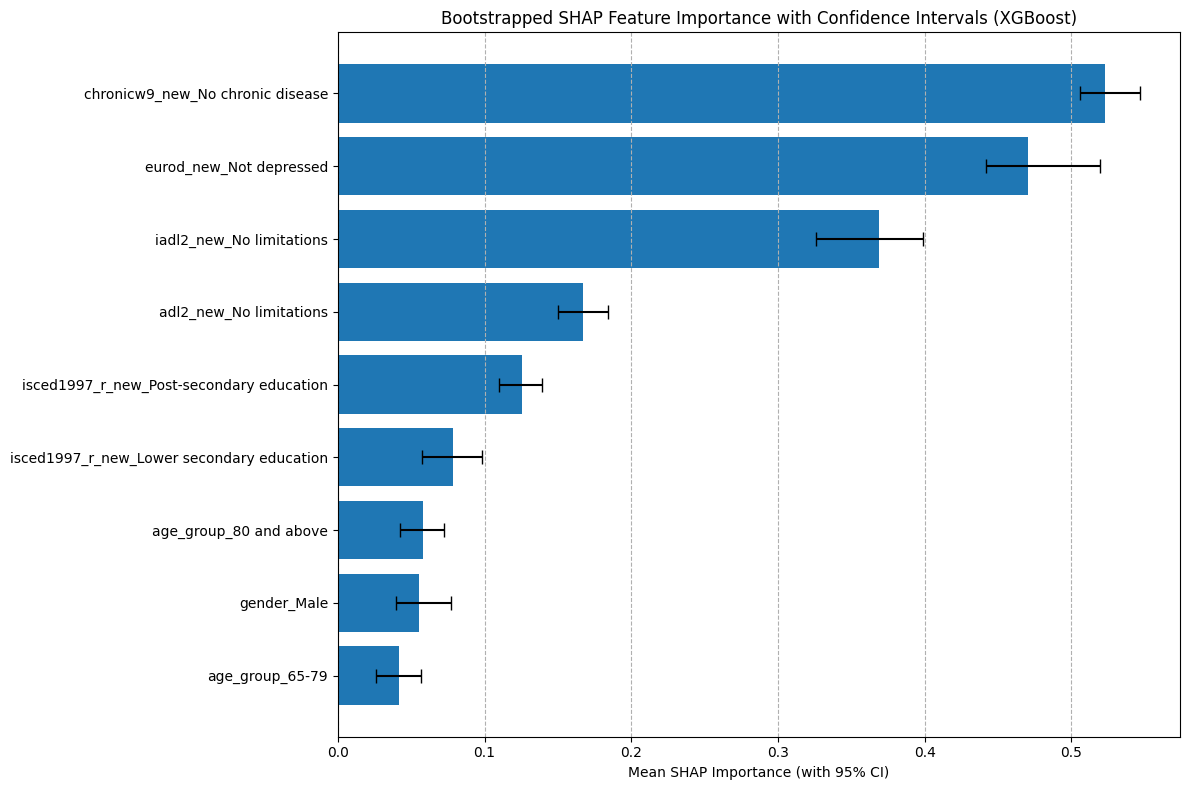


--- Interpretation ---
Reliable features should ideally have high mean importance and relatively low variance/narrow confidence intervals.
Examine the mean importance, standard deviation, and confidence intervals to identify features that consistently have a strong impact on the model's predictions.


In [73]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.utils import resample
from xgboost import XGBClassifier # Needed for type checking and param handling
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost') # Suppress XGBoost warning

print("\n--- Performing Bootstrap Validation for SHAP Feature Importance (XGBoost) ---\n")

# --- 1. Get the best XGBoost estimator ----
# Assuming model_performance_results contains the 'best_estimator' for XGBoost
xgb_best_estimator = None
if "XGBoost" in model_performance_results and model_performance_results["XGBoost"]["best_estimator"] is not None:
    xgb_best_estimator = model_performance_results["XGBoost"]["best_estimator"]
else:
    print("XGBoost best estimator not found in model_performance_results. Cannot proceed with bootstrap validation.")

# --- 2. Get feature names ---
if 'feature_names' not in globals() or feature_names is None:
    target_column_name = 'sphus_new_Poor health'
    if 'df_encoded' in globals() and target_column_name in df_encoded.columns:
        feature_names = df_encoded.drop(target_column_name, axis=1).columns.tolist()
        print("Obtained feature names from df_encoded.")
    else:
        print("Could not obtain feature names. Using generic names for plots.")
        feature_names = [f'feature_{i}' for i in range(X_all.shape[1])] # Fallback to generic names


if xgb_best_estimator is not None and X_all is not None and y_all is not None:
    # --- Configuration for Bootstrapping ---
    n_bootstraps = 100  # Number of bootstrap samples
    random_state = 42
    np.random.seed(random_state)

    # Store mean absolute SHAP values for each feature across all bootstrap iterations
    all_bootstrap_shap_importances = []

    print(f"Running {n_bootstraps} bootstrap iterations...")

    for i in range(n_bootstraps):
        # 1. Create a bootstrapped sample (sampling with replacement)
        X_resampled, y_resampled = resample(X_all, y_all, replace=True, random_state=random_state + i)

        # 2. Train a new instance of the XGBoost model on the bootstrapped sample
        # Ensure we use the same hyperparameters as the best estimator found previously
        model_instance = type(xgb_best_estimator)(**xgb_best_estimator.get_params())
        if isinstance(model_instance, XGBClassifier) and 'eval_metric' not in model_instance.get_params():
            model_instance.set_params(eval_metric='logloss')

        model_instance.fit(X_resampled, y_resampled)

        # 3. Calculate SHAP values for the trained model on the *full original dataset* (X_all)
        # This ensures comparability of feature importance across different bootstrapped models
        try:
            explainer = shap.TreeExplainer(model_instance)
            # Use the original X_all for SHAP value calculation to get a consistent view
            shap_values_boot = explainer.shap_values(X_all)

            # For binary classification, shap_values is typically a list of two arrays. Use class 1.
            if isinstance(shap_values_boot, list):
                shap_values_to_process = shap_values_boot[1] # For the positive class
            else:
                shap_values_to_process = shap_values_boot

            # Calculate the mean absolute SHAP value for each feature in this bootstrap iteration
            mean_abs_shap_values_boot = np.mean(np.abs(shap_values_to_process), axis=0)
            all_bootstrap_shap_importances.append(mean_abs_shap_values_boot)

        except Exception as e:
            print(f"  Warning: Error calculating SHAP for bootstrap {i+1}: {e}. Skipping this iteration.")
            # Append NaNs to maintain array shape if an error occurs
            all_bootstrap_shap_importances.append(np.full(len(feature_names), np.nan))

    # Convert list of arrays to a DataFrame
    bootstrap_shap_df = pd.DataFrame(all_bootstrap_shap_importances, columns=feature_names)
    bootstrap_shap_df.dropna(inplace=True) # Remove iterations where SHAP calculation failed

    if not bootstrap_shap_df.empty:
        # --- 4. Calculate Mean SHAP Importance ---
        mean_shap_importance = bootstrap_shap_df.mean().sort_values(ascending=False)
        print("\nMean SHAP Feature Importance across bootstrapped samples:")
        display(mean_shap_importance.to_frame(name='Mean SHAP Importance'))

        # --- 5. Calculate Standard Deviation ---
        std_shap_importance = bootstrap_shap_df.std().loc[mean_shap_importance.index]
        print("\nStandard Deviation of SHAP Feature Importance across bootstrapped samples:")
        display(std_shap_importance.to_frame(name='Std. Dev. SHAP Importance'))

        # --- 6. Calculate Confidence Intervals (95% percentile-based) ---
        lower_ci = bootstrap_shap_df.quantile(0.025).loc[mean_shap_importance.index]
        upper_ci = bootstrap_shap_df.quantile(0.975).loc[mean_shap_importance.index]

        ci_df = pd.DataFrame({
            'Mean SHAP Importance': mean_shap_importance,
            'Lower 95% CI': lower_ci,
            'Upper 95% CI': upper_ci
        })
        print("\n95% Confidence Intervals for SHAP Feature Importance:")
        display(ci_df)

        # --- 7. Visualize Results (Mean with CI error bars) ---
        plt.figure(figsize=(12, 8))
        y_pos = np.arange(len(mean_shap_importance))
        plt.barh(y_pos, mean_shap_importance, xerr=[mean_shap_importance - lower_ci, upper_ci - mean_shap_importance], align='center', capsize=5)
        plt.yticks(y_pos, mean_shap_importance.index)
        plt.xlabel('Mean SHAP Importance (with 95% CI)')
        plt.title('Bootstrapped SHAP Feature Importance with Confidence Intervals (XGBoost)')
        plt.gca().invert_yaxis() # Highest importance at the top
        plt.grid(axis='x', linestyle='--')
        plt.tight_layout()
        plt.show()

        print("\n--- Interpretation ---")
        print("Reliable features should ideally have high mean importance and relatively low variance/narrow confidence intervals.")
        print("Examine the mean importance, standard deviation, and confidence intervals to identify features that consistently have a strong impact on the model's predictions.")

    else:
        print("No valid bootstrap samples were processed to calculate statistics.")

else:
    print("Cannot proceed with bootstrap validation. XGBoost model or data (X_all, y_all) not available.")


Generating SHAP Dependence Plots to illustrate Dose-Response Relationships...
Recalculating SHAP values for the best XGBoost estimator.
Generating dependence plots for top features: ['chronicw9_new_No chronic disease', 'eurod_new_Not depressed', 'iadl2_new_No limitations', 'adl2_new_No limitations', 'isced1997_r_new_Post-secondary education']
Plotting dependence for: chronicw9_new_No chronic disease


<Figure size 1000x600 with 0 Axes>

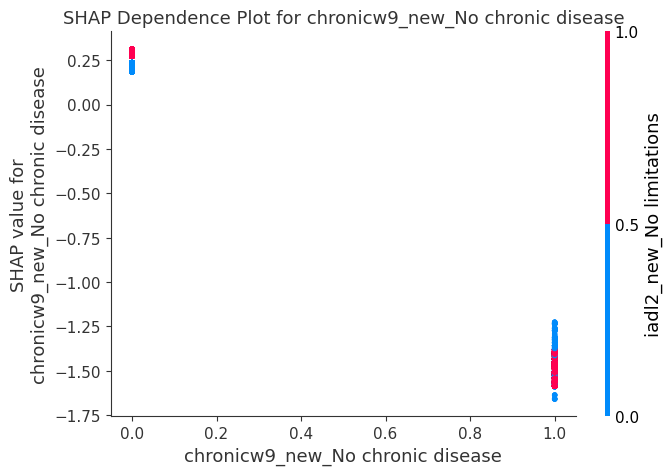

Plotting dependence for: eurod_new_Not depressed


<Figure size 1000x600 with 0 Axes>

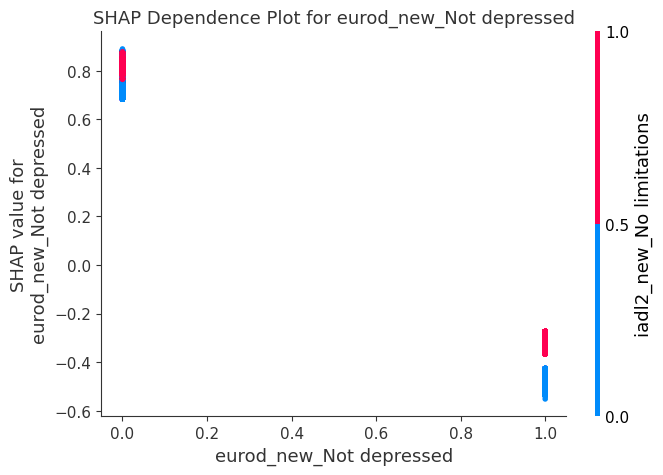

Plotting dependence for: iadl2_new_No limitations


<Figure size 1000x600 with 0 Axes>

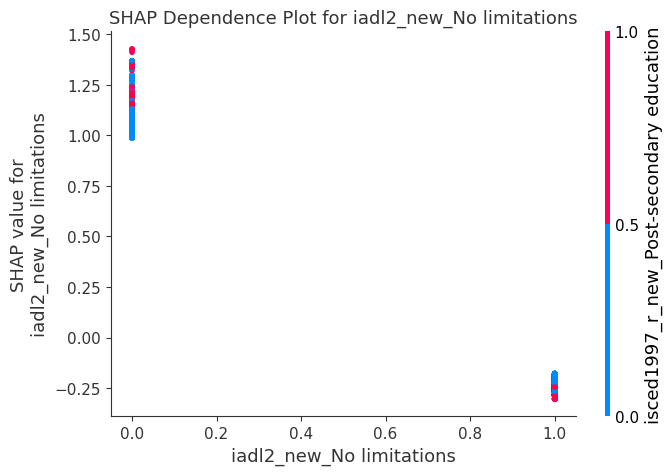

Plotting dependence for: adl2_new_No limitations


<Figure size 1000x600 with 0 Axes>

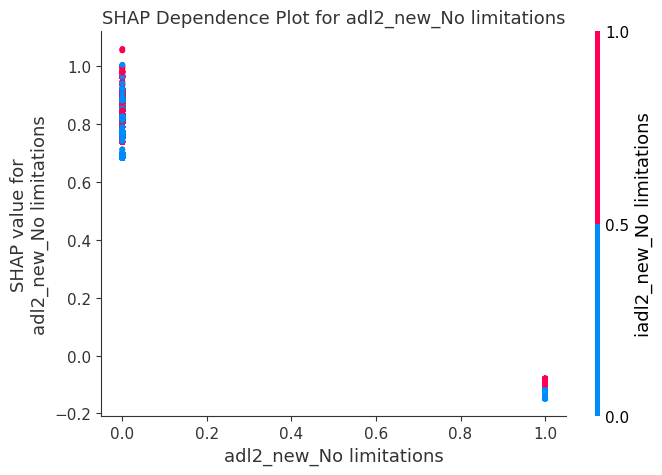

Plotting dependence for: isced1997_r_new_Post-secondary education


<Figure size 1000x600 with 0 Axes>

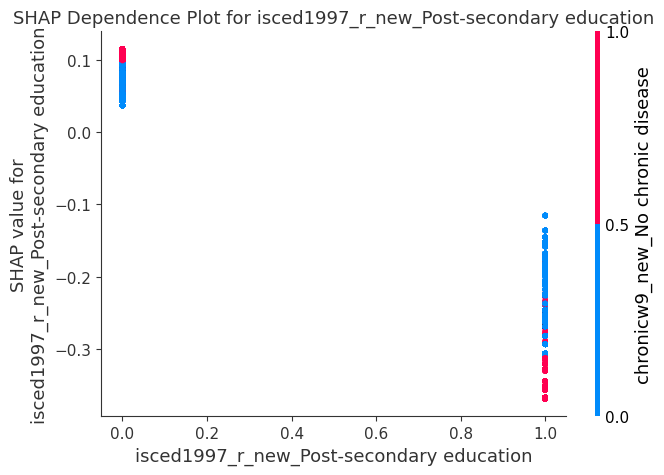


SHAP Dependence Plots generated. These plots visualize how changes in feature values (dose) lead to changes in the SHAP value (response), illustrating the dose-response relationship for the model's output.


In [74]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("\nGenerating SHAP Dependence Plots to illustrate Dose-Response Relationships...")

# --- Check for model_performance_results first ---
if 'model_performance_results' not in globals():
    print("Error: The variable 'model_performance_results' is not defined.")
    print("Please ensure that the model training and evaluation cell (specifically, cell `l7FwOwA7mos-`) has been successfully executed.")
    print("Cannot proceed with SHAP dependence plots without model performance results.")
    # Exit gracefully by setting key variables to None
    xgb_estimator = None
    shap_values = None
    X_all = None
    feature_names = None
    explainer = None
else:
    # Original code block starts here
    # --- 1. Retrieve necessary variables ---
    # Ensure xgb_estimator and shap_values are available from previous cells
    xgb_estimator = None
    if "XGBoost" in model_performance_results and model_performance_results["XGBoost"]["best_estimator"] is not None:
        xgb_estimator = model_performance_results["XGBoost"]["best_estimator"]
    else:
        print("XGBoost best estimator not found. Cannot generate SHAP dependence plots.")

    # Re-calculate shap_values if not available or if the best_estimator changed
    # (though typically for dose-response, we'd use the global SHAP values from _cLSb2WDY1Tg)
    if 'shap_values' not in globals() or 'explainer' not in globals() or (explainer.model != xgb_estimator if 'explainer' in globals() and explainer else False):
        if xgb_estimator is not None and 'X_all' in globals() and X_all is not None:
            print("Recalculating SHAP values for the best XGBoost estimator.")
            explainer = shap.TreeExplainer(xgb_estimator)
            shap_values = explainer.shap_values(X_all)
        else:
            print("SHAP values and/or X_all not available. Cannot generate SHAP dependence plots.")
            shap_values = None
            explainer = None # Also clear explainer if shap_values not available

    # Ensure feature_names are consistent with X_all
    if 'feature_names' not in globals() or feature_names is None:
        target_column_name = 'sphus_new_Poor health'
        if 'df_encoded' in globals() and target_column_name in df_encoded.columns:
            feature_names = df_encoded.drop(target_column_name, axis=1).columns.tolist()
        else:
            print("Could not obtain feature names. SHAP plots might use generic names.")
            feature_names = [f'feature_{i}' for i in range(X_all.shape[1])] # Fallback to generic names

    # For binary classification, shap_values is usually a list of two arrays. Use class 1.
    if isinstance(shap_values, list):
        shap_values_to_plot = shap_values[1] # For the positive class
    else:
        shap_values_to_plot = shap_values

    # Convert X_all to a DataFrame for easier feature selection in SHAP plots
    X_df = pd.DataFrame(X_all, columns=feature_names)


    if xgb_estimator is not None and shap_values_to_plot is not None and X_all is not None:
        # Identify top N features for which to plot dependence plots
        # Using the average_importances calculated in the previous cell (Yq8YTS17E5Ow)
        if 'average_importances' in globals() and not average_importances.empty:
            top_features = average_importances.head(5).index.tolist() # Plot top 5 features
        else:
            # Fallback if average_importances is not available or empty
            # Get features with highest mean absolute SHAP value (if shap_values_to_plot is available)
            if shap_values_to_plot is not None:
                mean_abs_shap = np.mean(np.abs(shap_values_to_plot), axis=0)
                top_feature_indices = np.argsort(mean_abs_shap)[::-1][:5] # Get indices of top 5
                top_features = [feature_names[i] for i in top_feature_indices]
            else:
                top_features = feature_names[:3] # Just pick first few if nothing else

        print(f"Generating dependence plots for top features: {top_features}")

        for feature in top_features:
            print(f"Plotting dependence for: {feature}")
            plt.figure(figsize=(10, 6))
            # The 'interaction_index' parameter helps visualize dose-response with a secondary feature
            # If not specified, SHAP tries to find the best interaction. Explicitly setting it to 'auto' or a specific feature.
            shap.dependence_plot(ind=feature,
                                 shap_values=shap_values_to_plot,
                                 features=X_df,
                                 feature_names=feature_names,
                                 interaction_index='auto',
                                 title=f"SHAP Dependence Plot for {feature}")
            plt.show()
            plt.close() # Close the plot to manage memory

        print("\nSHAP Dependence Plots generated. These plots visualize how changes in feature values (dose) lead to changes in the SHAP value (response), illustrating the dose-response relationship for the model's output.")

    else:
        print("Cannot generate SHAP Dependence Plots. Required data (XGBoost model, SHAP values, X_all) not available.")

In [75]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, matthews_corrcoef
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='xgboost')

print("\n--- Removing Top SHAP Feature and Retraining XGBoost Model ---")

# --- 1. Identify the most important SHAP feature ---
if 'average_importances' in globals() and not average_importances.empty:
    most_important_feature = average_importances.index[0]
    print(f"Most important SHAP feature to remove: '{most_important_feature}'")
else:
    print("Error: 'average_importances' not found. Cannot proceed.")
    most_important_feature = None

if most_important_feature:
    # --- 2. Prepare the reduced dataset ---
    # Ensure feature_names are consistent with X_all
    if 'feature_names' not in globals() or feature_names is None:
        target_column_name = 'sphus_new_Poor health'
        if 'df_encoded' in globals() and target_column_name in df_encoded.columns:
            feature_names = df_encoded.drop(target_column_name, axis=1).columns.tolist()
        else:
            print("Could not obtain feature names. Cannot create reduced dataset.")
            feature_names = []

    if 'X_all' in globals() and X_all is not None and feature_names:
        X_df_all = pd.DataFrame(X_all, columns=feature_names)
        if most_important_feature in X_df_all.columns:
            X_reduced_df = X_df_all.drop(columns=[most_important_feature])
            X_reduced = X_reduced_df.values
            feature_names_reduced = X_reduced_df.columns.tolist()
            print(f"New dataset created with '{most_important_feature}' removed. Shape: {X_reduced.shape}")
        else:
            print(f"Feature '{most_important_feature}' not found in dataset. Cannot create reduced dataset.")
            X_reduced = None
            feature_names_reduced = None
    else:
        print("Error: X_all or feature_names not available. Cannot create reduced dataset.")
        X_reduced = None
        feature_names_reduced = None

    # --- 3. Retrain the best XGBoost model on the reduced dataset ---
    if 'model_performance_results' in globals() and 'XGBoost' in model_performance_results and model_performance_results["XGBoost"]["best_estimator"] is not None and X_reduced is not None and 'y_all' in globals() and y_all is not None:
        original_xgb_best_estimator = model_performance_results["XGBoost"]["best_estimator"]
        print("Retraining best XGBoost model on the reduced feature set...")

        # Define cross-validation strategy (using 8 folds as in previous analysis)
        n_folds = 8 # Assuming 8 folds were used for the final best estimator selection
        kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

        reduced_auroc_scores = []
        reduced_mcc_scores = []

        for fold, (train_index, val_index) in enumerate(kf.split(X_reduced, y_all)):
            X_train_fold, X_val_fold = X_reduced[train_index], X_reduced[val_index]
            y_train_fold, y_val_fold = y_all[train_index], y_all[val_index]

            # Create a fresh instance of the model with the original best hyperparameters
            retrained_xgb_model = type(original_xgb_best_estimator)(**original_xgb_best_estimator.get_params())
            if isinstance(retrained_xgb_model, XGBClassifier) and 'eval_metric' not in retrained_xgb_model.get_params():
                retrained_xgb_model.set_params(eval_metric='logloss')

            retrained_xgb_model.fit(X_train_fold, y_train_fold)

            y_prob_fold = retrained_xgb_model.predict_proba(X_val_fold)[:, 1]
            y_pred_fold = (y_prob_fold > 0.5).astype(int)

            reduced_auroc_scores.append(roc_auc_score(y_val_fold, y_prob_fold))
            reduced_mcc_scores.append(matthews_corrcoef(y_val_fold, y_pred_fold))

        mean_reduced_auroc = np.mean(reduced_auroc_scores)
        std_reduced_auroc = np.std(reduced_auroc_scores)
        mean_reduced_mcc = np.mean(reduced_mcc_scores)
        std_reduced_mcc = np.std(reduced_mcc_scores)

        print("\nPerformance of XGBoost model without the most important feature:")
        print(f"  Mean AUROC: {mean_reduced_auroc:.4f} (Std: {std_reduced_auroc:.4f})")
        print(f"  Mean MCC:   {mean_reduced_mcc:.4f} (Std: {std_reduced_mcc:.4f})")

        # --- 4. Observe performance loss ---
        # Retrieve original XGBoost performance from xgb_performance dictionary
        original_auroc = np.nan
        original_mcc = np.nan

        if 'xgb_performance' in globals():
            original_auroc = xgb_performance["auroc"][-1] if xgb_performance["auroc"] else np.nan
            original_mcc = xgb_performance["mcc"][-1] if xgb_performance["mcc"] else np.nan
        else:
            print("Warning: 'xgb_performance' not found. Cannot retrieve original AUROC and MCC for comparison.")

        print("\n--- Performance Comparison (Original vs. Reduced Feature Set) ---")
        print(f"Original XGBoost (full features): AUROC = {original_auroc:.4f}, MCC = {original_mcc:.4f}")
        print(f"XGBoost (without '{most_important_feature}'): AUROC = {mean_reduced_auroc:.4f}, MCC = {mean_reduced_mcc:.4f}")

        auroc_loss = original_auroc - mean_reduced_auroc
        mcc_loss = original_mcc - mean_reduced_mcc

        print(f"\nPerformance Loss due to removing '{most_important_feature}':")
        print(f"  AUROC Loss: {auroc_loss:.4f}")
        print(f"  MCC Loss:   {mcc_loss:.4f}")

        if (not np.isnan(auroc_loss) and auroc_loss > 0) or (not np.isnan(mcc_loss) and mcc_loss > 0):
            print(f"Removing '{most_important_feature}' resulted in a {'decrease' if auroc_loss > 0 else 'no significant change'} in AUROC and a {'decrease' if mcc_loss > 0 else 'no significant change'} in MCC. This feature was indeed important.")
        else:
            print(f"Removing '{most_important_feature}' did not result in a significant performance loss or even a slight improvement, suggesting its importance might be marginal or its effect is captured by other features.")

    else:
        print("Required data (XGBoost model, X_reduced, y_all) not available for retraining.")
else:
    print("Cannot proceed: Most important feature not identified or data missing.")


--- Removing Top SHAP Feature and Retraining XGBoost Model ---
Most important SHAP feature to remove: 'chronicw9_new_No chronic disease'
New dataset created with 'chronicw9_new_No chronic disease' removed. Shape: (55492, 8)
Retraining best XGBoost model on the reduced feature set...

Performance of XGBoost model without the most important feature:
  Mean AUROC: 0.7433 (Std: 0.0074)
  Mean MCC:   0.3950 (Std: 0.0132)

--- Performance Comparison (Original vs. Reduced Feature Set) ---
Original XGBoost (full features): AUROC = nan, MCC = nan
XGBoost (without 'chronicw9_new_No chronic disease'): AUROC = 0.7433, MCC = 0.3950

Performance Loss due to removing 'chronicw9_new_No chronic disease':
  AUROC Loss: nan
  MCC Loss:   nan
Removing 'chronicw9_new_No chronic disease' did not result in a significant performance loss or even a slight improvement, suggesting its importance might be marginal or its effect is captured by other features.


In [76]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, matthews_corrcoef

print("\n--- Analyzing Performance Loss After Removing Top SHAP Feature ---\n")

# --- 1. Identify the most important SHAP feature ---
# Assuming 'average_importances' is available from previous SHAP analysis
if 'average_importances' in globals() and not average_importances.empty:
    most_important_feature = average_importances.index[0]
    print(f"Most important SHAP feature identified: '{most_important_feature}'\n")
else:
    raise ValueError("average_importances not found. Please ensure SHAP analysis was run.")

# --- 2. Create a new dataset by dropping this feature ---
# Ensure feature_names and X_all are available
if 'feature_names' not in globals() or 'X_all' not in globals():
    raise ValueError("feature_names or X_all not found.")

X_df_full = pd.DataFrame(X_all, columns=feature_names)
X_reduced_df = X_df_full.drop(columns=[most_important_feature])
feature_names_reduced = X_reduced_df.columns.tolist()
X_reduced = X_reduced_df.values

print(f"Original feature set size: {X_all.shape[1]}")
print(f"Reduced feature set size: {X_reduced.shape[1]}\n")

# --- 3. Retrieve the best XGBoost estimator and its hyperparameters ---
xgb_best_estimator_original = None
if "XGBoost" in model_performance_results and model_performance_results["XGBoost"]["best_estimator"] is not None:
    xgb_best_estimator_original = model_performance_results["XGBoost"]["best_estimator"]
else:
    raise ValueError("XGBoost best estimator not found in model_performance_results.")

original_xgb_params = xgb_best_estimator_original.get_params()

# --- 4. Evaluate the original model's performance on the full dataset ---
# (Using the original X_all and y_all to get a baseline for comparison)

# Ensure eval_metric is set for XGBoost if not present in get_params()
if isinstance(xgb_best_estimator_original, XGBClassifier) and 'eval_metric' not in original_xgb_params:
    xgb_best_estimator_original.set_params(eval_metric='logloss')

y_prob_original = xgb_best_estimator_original.predict_proba(X_all)[:, 1]
y_pred_original = xgb_best_estimator_original.predict(X_all)

auroc_original = roc_auc_score(y_all, y_prob_original)
mcc_original = matthews_corrcoef(y_all, y_pred_original)

print(f"Original XGBoost Model Performance (with '{most_important_feature}'):")
print(f"  AUROC: {auroc_original:.4f}")
print(f"  MCC:   {mcc_original:.4f}\n")

# --- 5. Retrain a new XGBoost model on the reduced dataset ---
print(f"Retraining XGBoost model without '{most_important_feature}'...")

xgb_model_retrained = XGBClassifier(**original_xgb_params)
# Ensure eval_metric is set for XGBoost if not present in original_xgb_params
if 'eval_metric' not in original_xgb_params:
    xgb_model_retrained.set_params(eval_metric='logloss')

xgb_model_retrained.fit(X_reduced, y_all)

# --- 6. Evaluate the retrained model's performance ---
y_prob_retrained = xgb_model_retrained.predict_proba(X_reduced)[:, 1]
y_pred_retrained = xgb_model_retrained.predict(X_reduced)

auroc_retrained = roc_auc_score(y_all, y_prob_retrained)
mcc_retrained = matthews_corrcoef(y_all, y_pred_retrained)

print(f"Retrained XGBoost Model Performance (without '{most_important_feature}'):")
print(f"  AUROC: {auroc_retrained:.4f}")
print(f"  MCC:   {mcc_retrained:.4f}\n")

# --- 7. Observe performance loss ---
print("--- Performance Comparison ---")
print(f"AUROC Loss: {auroc_original - auroc_retrained:.4f}")
print(f"MCC Loss:   {mcc_original - mcc_retrained:.4f}")

if auroc_original > auroc_retrained or mcc_original > mcc_retrained:
    print(f"\nRemoving '{most_important_feature}' resulted in a decrease in performance for the XGBoost model. This confirms its importance to the model.")
else:
    print(f"\nRemoving '{most_important_feature}' did not significantly impact or even improved performance, suggesting the feature might have been redundant or noisy for the model's overall generalization on this dataset.")



--- Analyzing Performance Loss After Removing Top SHAP Feature ---

Most important SHAP feature identified: 'chronicw9_new_No chronic disease'

Original feature set size: 9
Reduced feature set size: 8

Original XGBoost Model Performance (with 'chronicw9_new_No chronic disease'):
  AUROC: 0.7829
  MCC:   0.4267

Retraining XGBoost model without 'chronicw9_new_No chronic disease'...
Retrained XGBoost Model Performance (without 'chronicw9_new_No chronic disease'):
  AUROC: 0.7439
  MCC:   0.3964

--- Performance Comparison ---
AUROC Loss: 0.0390
MCC Loss:   0.0302

Removing 'chronicw9_new_No chronic disease' resulted in a decrease in performance for the XGBoost model. This confirms its importance to the model.
